In [1]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '22')
mpl.rc('xtick', labelsize=20) 
mpl.rc('ytick', labelsize=20)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [2]:
# Carga de archivos
dir_tanh2_m1 = "./data/var_M/M_2.435e18/"
dir_tanh2_m2 = "./data/var_M/M_2.435e19/"
dir_tanh2_m3 = "./data/var_M/M_2.435e20/"
dir_tanh2_m4 = "./data/var_M/M_2.435e22/"

# Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

In [3]:
def load_scale_factor(folder):
    return np.loadtxt(os.path.join(folder, "average_scale_factor.txt"))

# Load all scale factor datasets
aDat_tanh2_m1 = load_scale_factor(dir_tanh2_m1)
aDat_tanh2_m2 = load_scale_factor(dir_tanh2_m2)
aDat_tanh2_m3 = load_scale_factor(dir_tanh2_m3)
aDat_tanh2_m4 = load_scale_factor(dir_tanh2_m4)


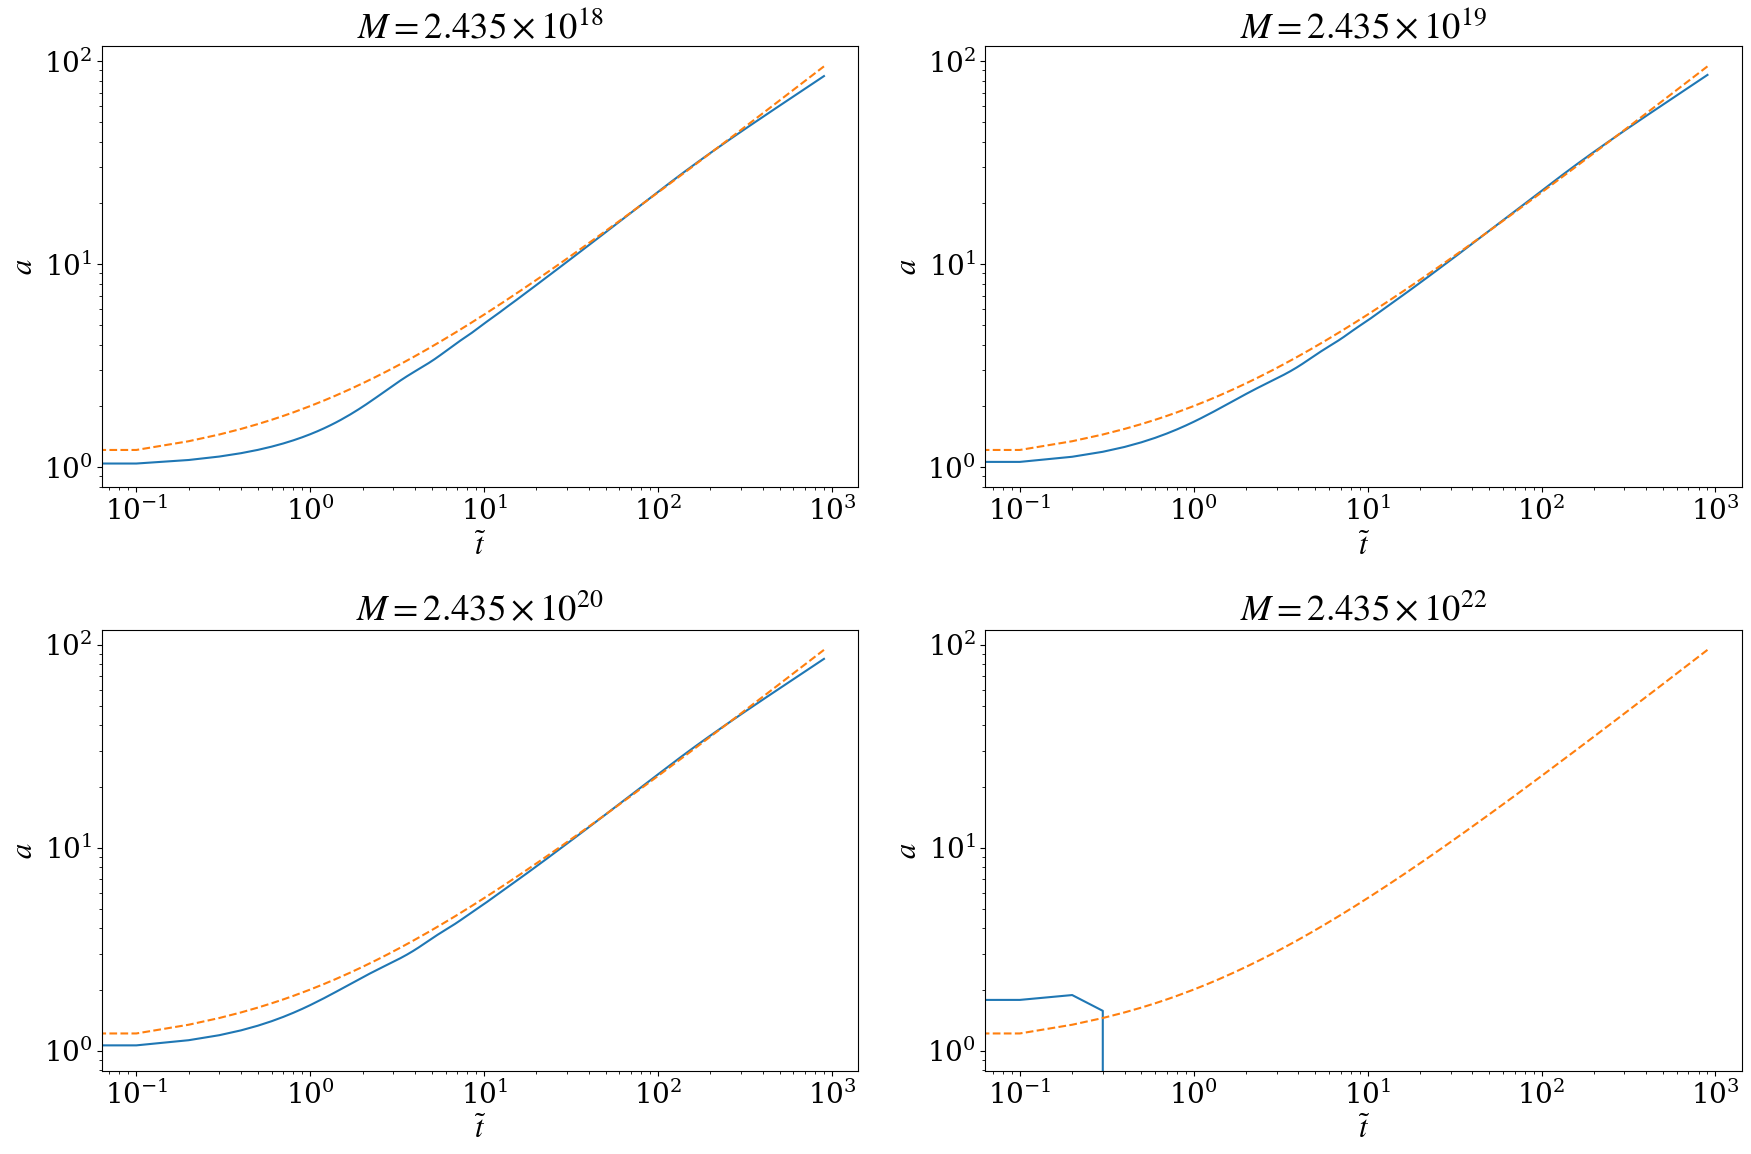

In [4]:
def plot_scale_factor_case(aDat_tanh2, q_labels):
    plt.figure(figsize=(18, 12))

    # Tanh2 arriba
    for idx in range(4):
        plt.subplot(2, 2, idx+1)
        plt.plot(aDat_tanh2[idx][:, 0], aDat_tanh2[idx][:, 1])
        plt.plot(aDat_tanh2[idx][:, 0], aDat_tanh2[idx][:, 0]**(2/3) + 1, "--")
        plt.ylabel("$a$")
        plt.xlabel(r'$\tilde t$')
        plt.title(q_labels[idx])
        plt.xscale("log")
        plt.yscale("log")

    plt.tight_layout()
    plt.show()

q_labels = [
    r"$M = 2.435 \times 10^{18}$",
    r"$M = 2.435 \times 10^{19}$",
    r"$M = 2.435 \times 10^{20}$",
    r"$M = 2.435 \times 10^{22}$",
]

plot_scale_factor_case([aDat_tanh2_m1, aDat_tanh2_m2, aDat_tanh2_m3, aDat_tanh2_m4], q_labels)

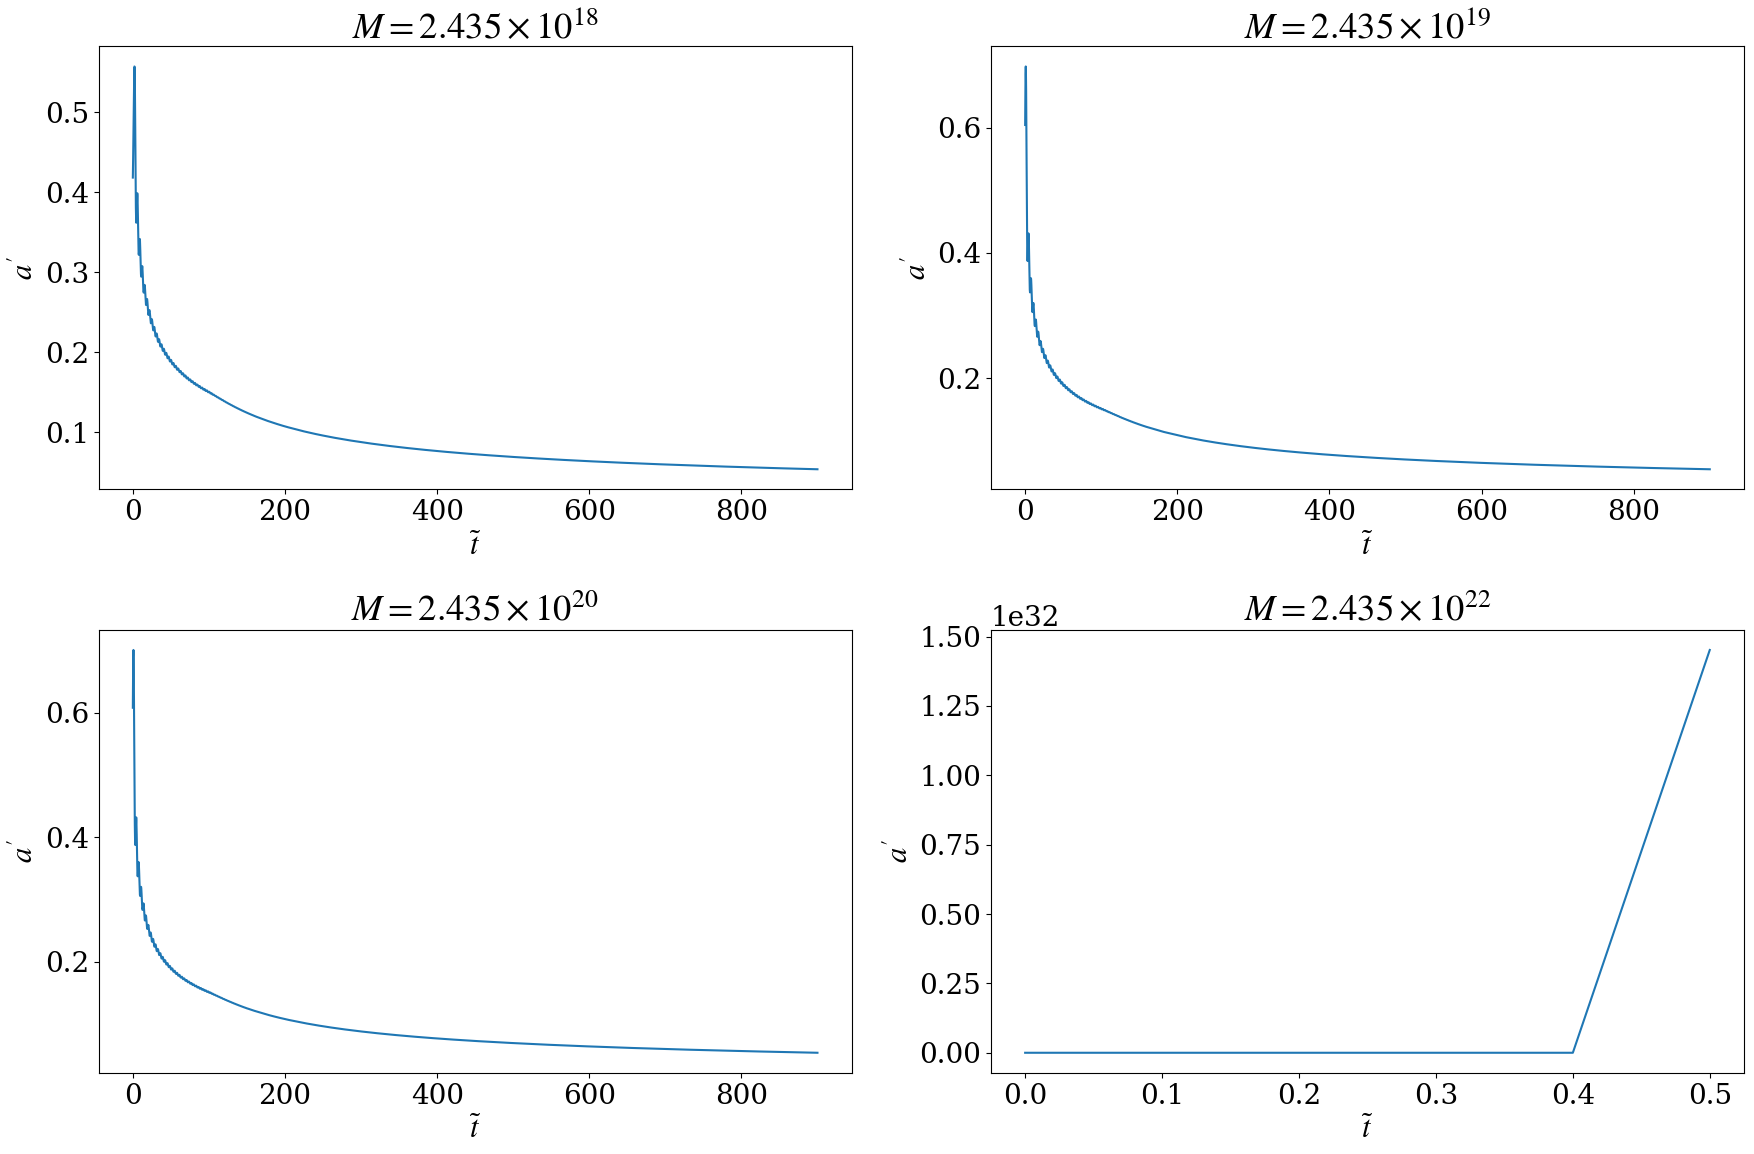

In [5]:
def plot_scale_factor_derivative_case(aDat_tanh2, q_labels):
    plt.figure(figsize=(18, 12))

    # Tanh2 arriba
    for idx in range(4):
        plt.subplot(2, 2, idx+1)
        plt.plot(aDat_tanh2[idx][:, 0], aDat_tanh2[idx][:, 2])
        plt.ylabel("$a'$")
        plt.xlabel(r'$\tilde t$')
        plt.title(q_labels[idx])
    
    plt.tight_layout()
    plt.show()
    
plot_scale_factor_derivative_case([aDat_tanh2_m1, aDat_tanh2_m2, aDat_tanh2_m3, aDat_tanh2_m4], q_labels)

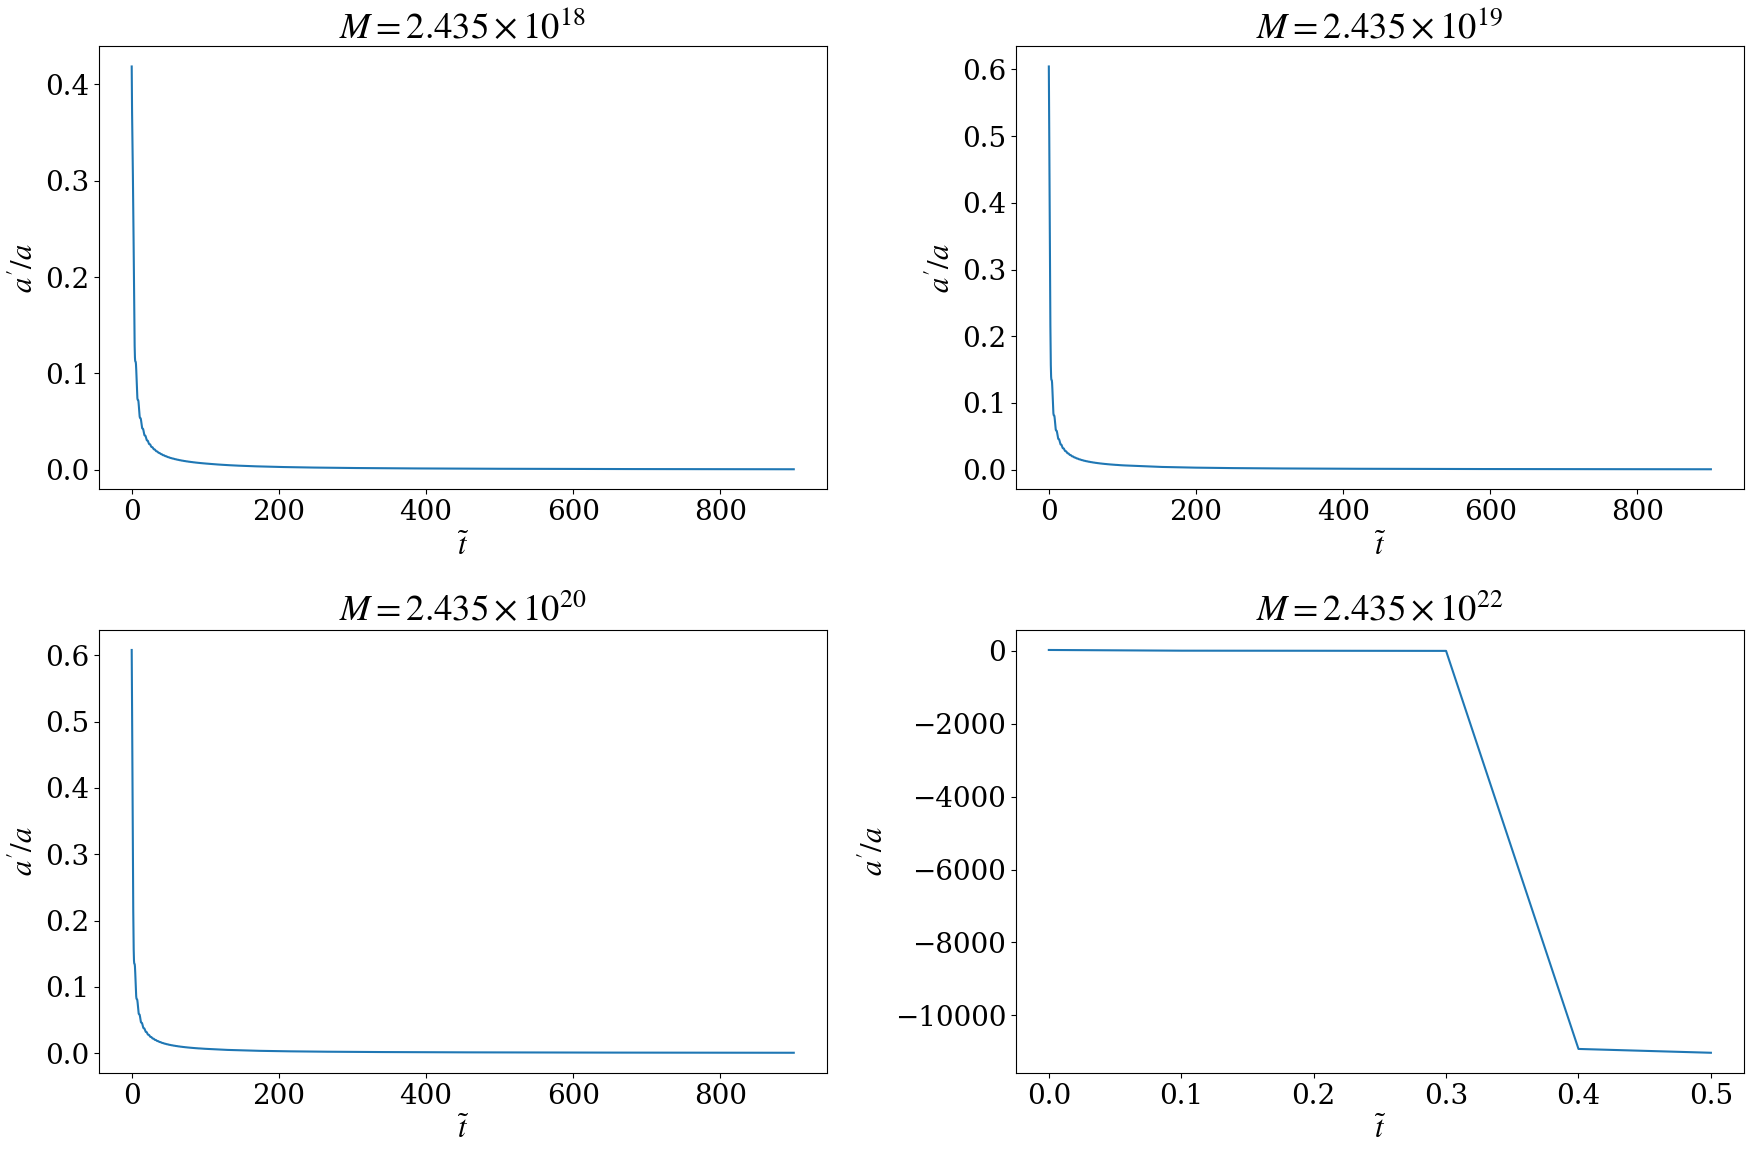

In [6]:
def plot_scale_factor_ratio_case(aDat_tanh2, q_labels):
    plt.figure(figsize=(18, 12))

    # Tanh2 arriba
    for idx in range(4):
        plt.subplot(2, 2, idx+1)
        plt.plot(aDat_tanh2[idx][:, 0], aDat_tanh2[idx][:, 3])  # Cambia a [:, 3] para a'/a
        plt.ylabel("$a'/a$")
        plt.xlabel(r'$\tilde t$')
        plt.title(q_labels[idx])

    plt.tight_layout()
    plt.show()

plot_scale_factor_ratio_case([aDat_tanh2_m1, aDat_tanh2_m2, aDat_tanh2_m3, aDat_tanh2_m4], q_labels)

# Volume average of fields

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

In [7]:
# Define a function for the plots, as we are gonna do 
# the same for both fields
def plot_fld(fldDat, fldNum="", aDat=None):
    plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,1])
    plt.xlabel("$\\tilde\eta$")
    plt.ylabel("$a\cdot\langle\phi_"+ fldNum +" \\rangle$")

## Field $0$ (inflaton)

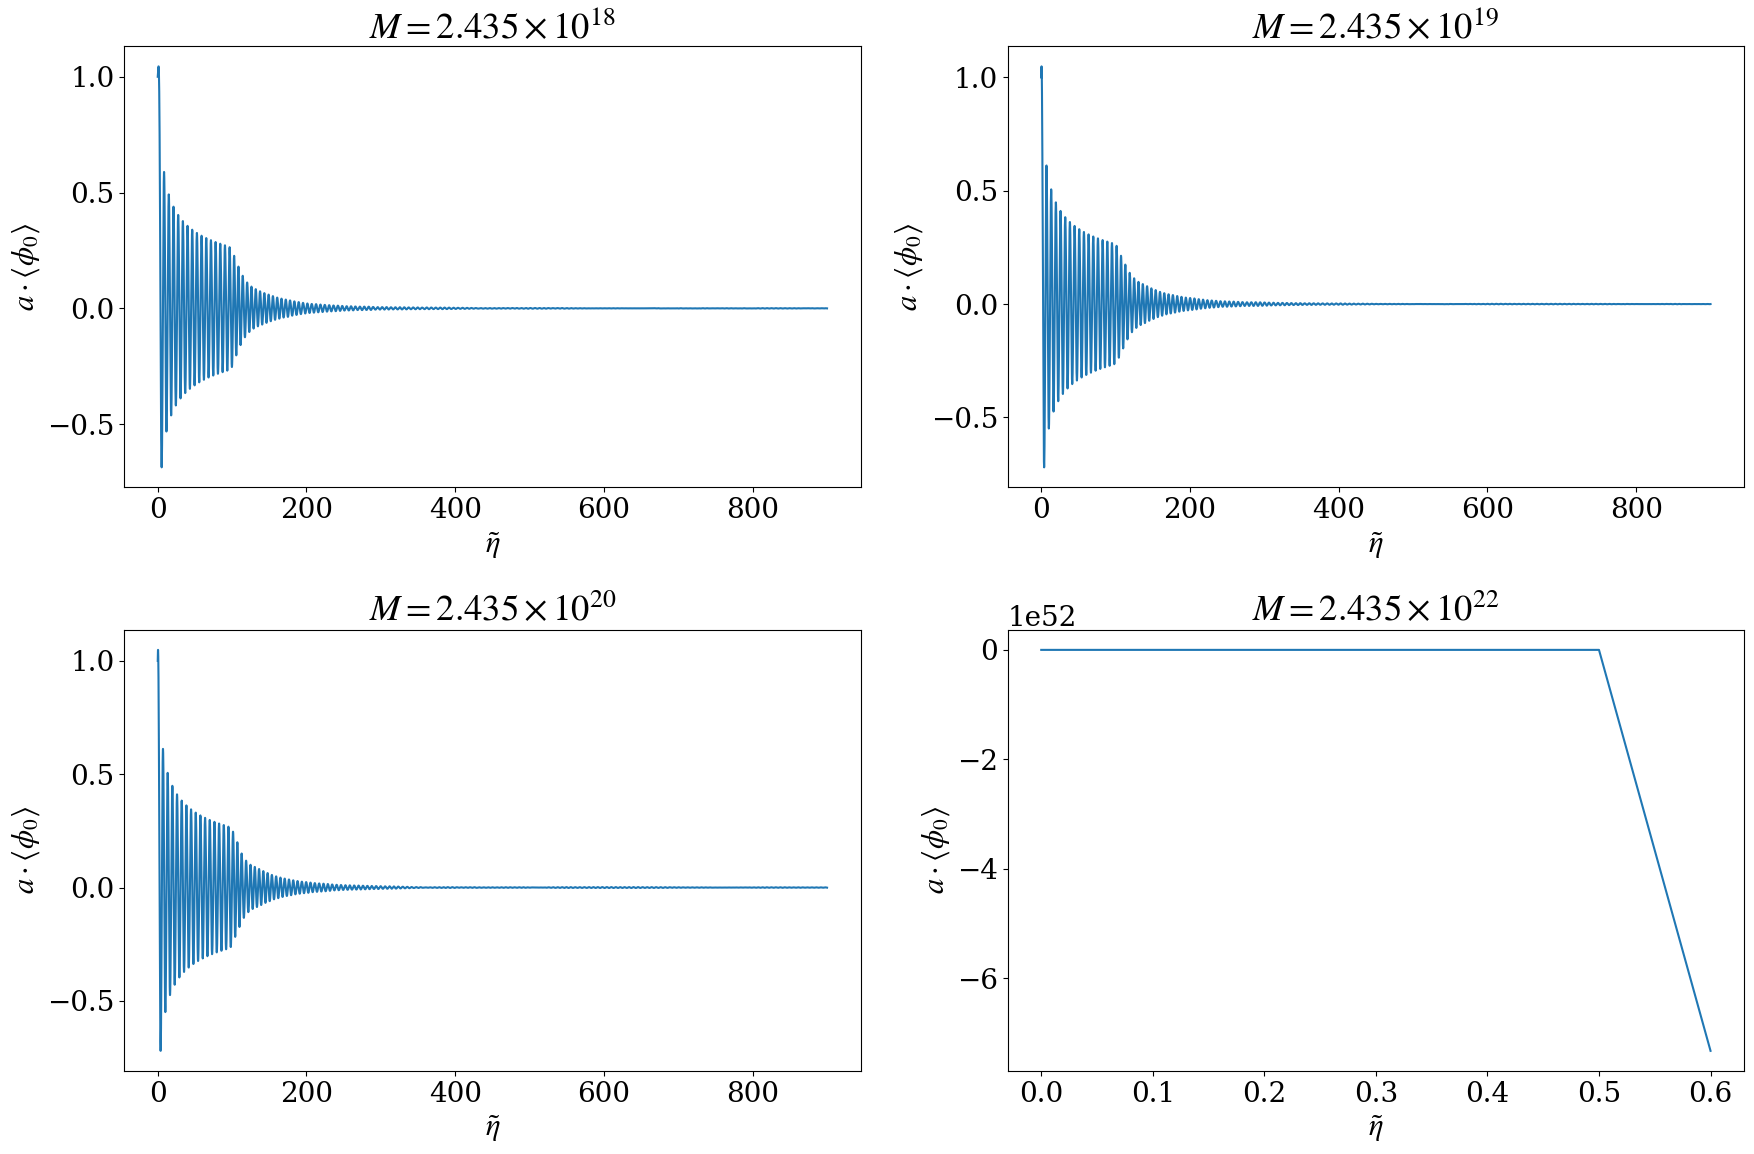

In [8]:
infDat_tanh2_m1 = np.loadtxt(dir_tanh2_m1 + "average_scalar_0.txt")
infDat_tanh2_m2 = np.loadtxt(dir_tanh2_m2 + "average_scalar_0.txt")
infDat_tanh2_m3 = np.loadtxt(dir_tanh2_m3 + "average_scalar_0.txt")
infDat_tanh2_m4 = np.loadtxt(dir_tanh2_m4 + "average_scalar_0.txt")

def plot_inflaton_case(infDat_tanh2, aDat_tanh2, q_labels):
    plt.figure(figsize=(18, 12))

    for idx in range(4):
        plt.subplot(2, 2, idx+1)
        plot_fld(infDat_tanh2[idx], "0", aDat_tanh2[idx])
        plt.title(q_labels[idx])

    plt.tight_layout()
    plt.show()

plot_inflaton_case([infDat_tanh2_m1, infDat_tanh2_m2, infDat_tanh2_m3, infDat_tanh2_m4], [aDat_tanh2_m1, aDat_tanh2_m2, aDat_tanh2_m3, aDat_tanh2_m4], q_labels)

## Field $1$ (daughter field)

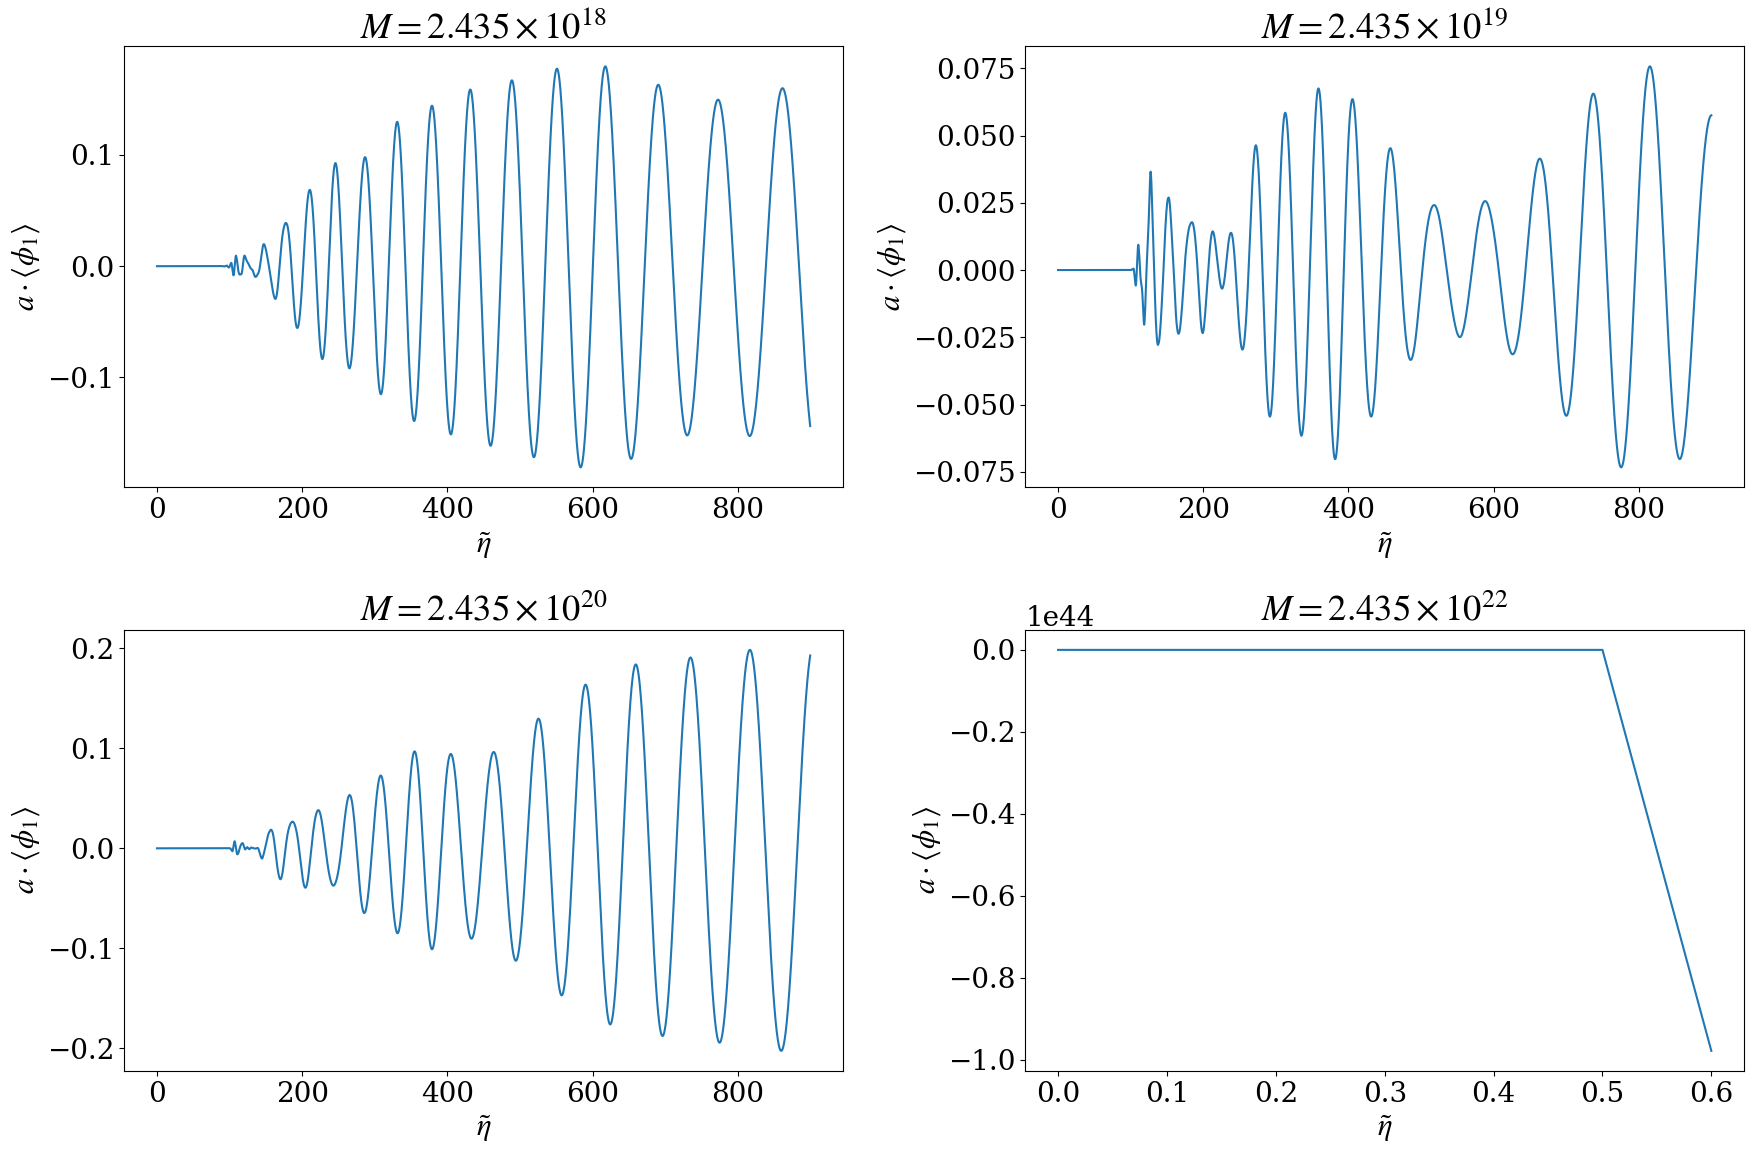

In [9]:
infDat_tanh2_m1 = np.loadtxt(dir_tanh2_m1 + "average_scalar_1.txt")
infDat_tanh2_m2 = np.loadtxt(dir_tanh2_m2 + "average_scalar_1.txt")
infDat_tanh2_m3 = np.loadtxt(dir_tanh2_m3 + "average_scalar_1.txt")
infDat_tanh2_m4 = np.loadtxt(dir_tanh2_m4 + "average_scalar_1.txt")

def plot_inflaton_case(infDat_tanh2, aDat_tanh2, q_labels):
    plt.figure(figsize=(18, 12))

    for idx in range(4):
        plt.subplot(2, 2, idx+1)
        plot_fld(infDat_tanh2[idx], "1", aDat_tanh2[idx])
        plt.title(q_labels[idx])

    plt.tight_layout()
    plt.show()

plot_inflaton_case([infDat_tanh2_m1, infDat_tanh2_m2, infDat_tanh2_m3, infDat_tanh2_m4], [aDat_tanh2_m1, aDat_tanh2_m2, aDat_tanh2_m3, aDat_tanh2_m4], q_labels)

# "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)

The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

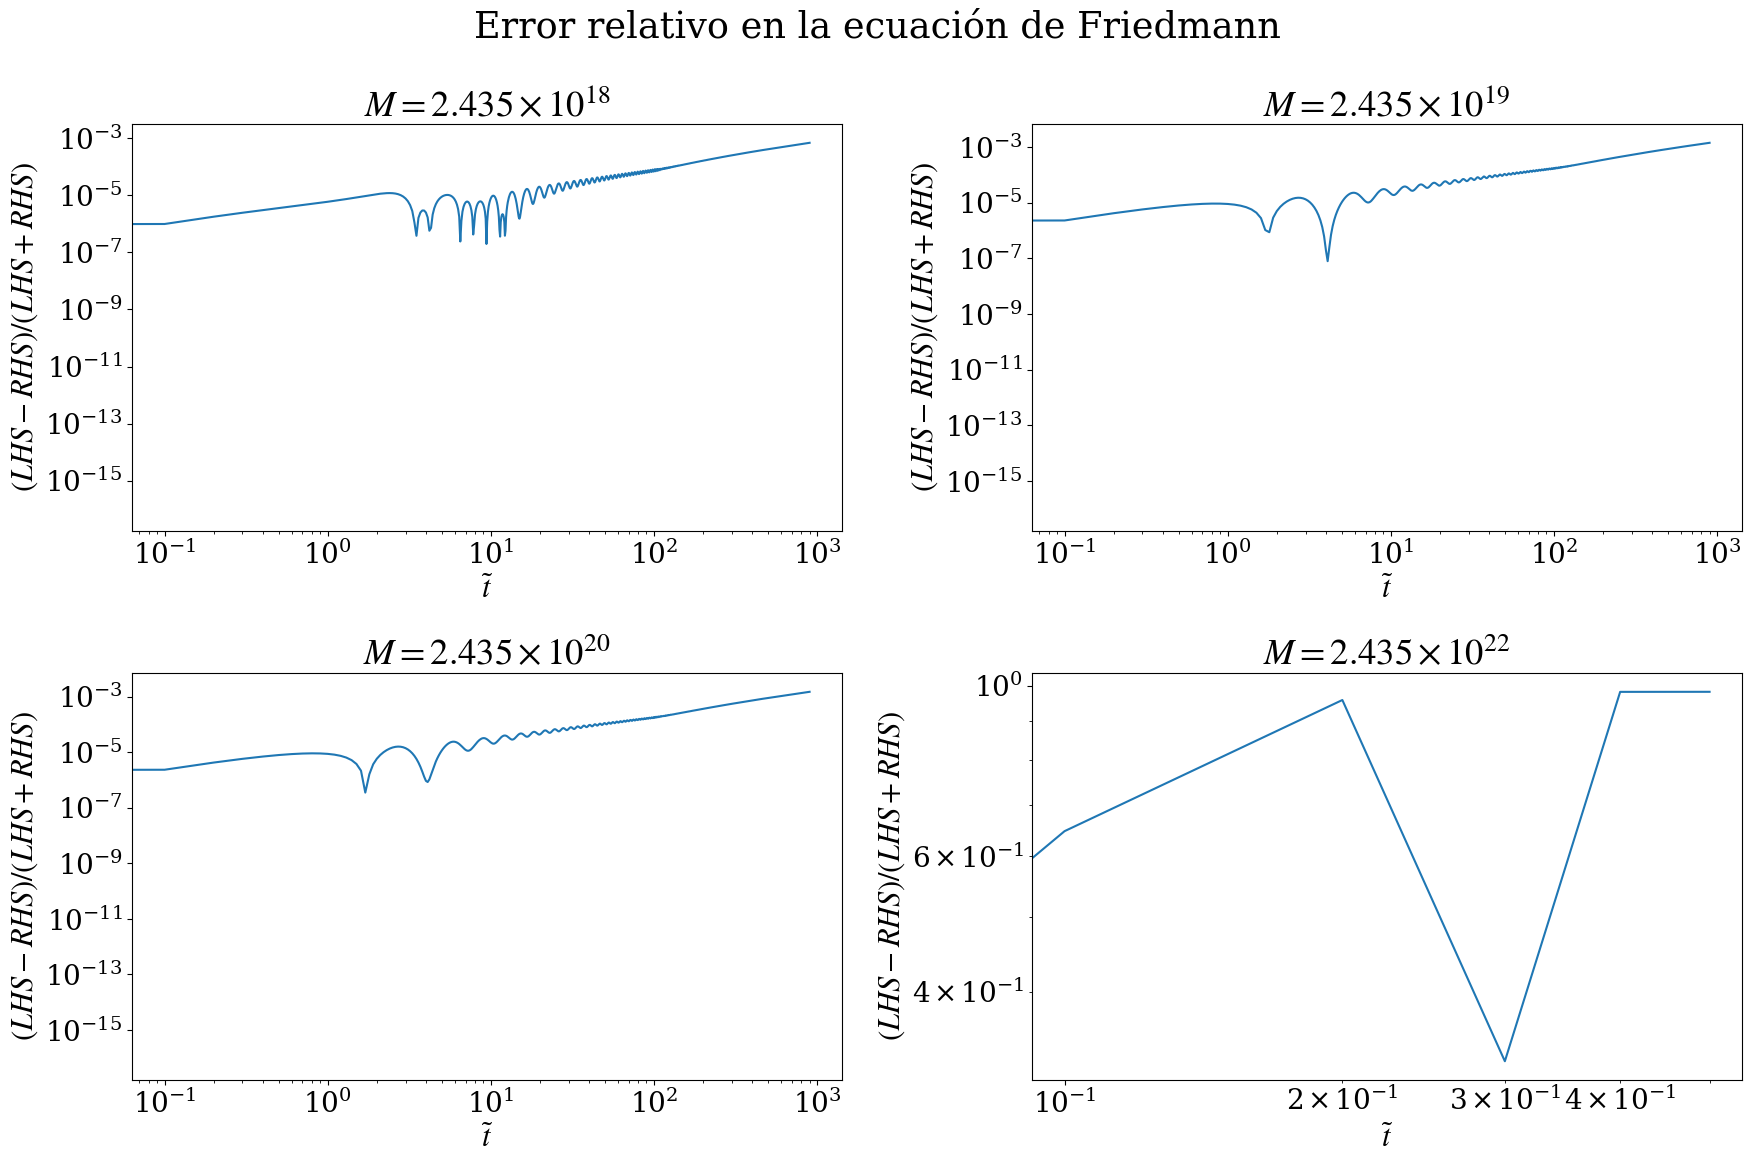

In [10]:
enConsDat_tanh2_m1 = np.loadtxt(dir_tanh2_m1 + "average_energy_conservation.txt")
enConsDat_tanh2_m2 = np.loadtxt(dir_tanh2_m2 + "average_energy_conservation.txt")
enConsDat_tanh2_m3 = np.loadtxt(dir_tanh2_m3 + "average_energy_conservation.txt")
enConsDat_tanh2_m4 = np.loadtxt(dir_tanh2_m4 + "average_energy_conservation.txt")

def plot_energy_conservation_case(enConsDat_tanh2, q_labels):
    plt.figure(figsize=(18, 12))

    for idx in range(4):
        plt.subplot(2, 2, idx+1)
        plt.plot(enConsDat_tanh2[idx][:,0], np.abs(enConsDat_tanh2[idx][:,1]))
        plt.title(q_labels[idx])
        plt.yscale('log')
        plt.xscale('log')
        plt.xlabel(r'$\tilde t$')
        plt.ylabel(r'$(LHS - RHS)/(LHS + RHS)$')

    plt.suptitle(r"Error relativo en la ecuación de Friedmann")
    plt.tight_layout()
    plt.show()

plot_energy_conservation_case([enConsDat_tanh2_m1, enConsDat_tanh2_m2, enConsDat_tanh2_m3, enConsDat_tanh2_m4], q_labels)

# Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

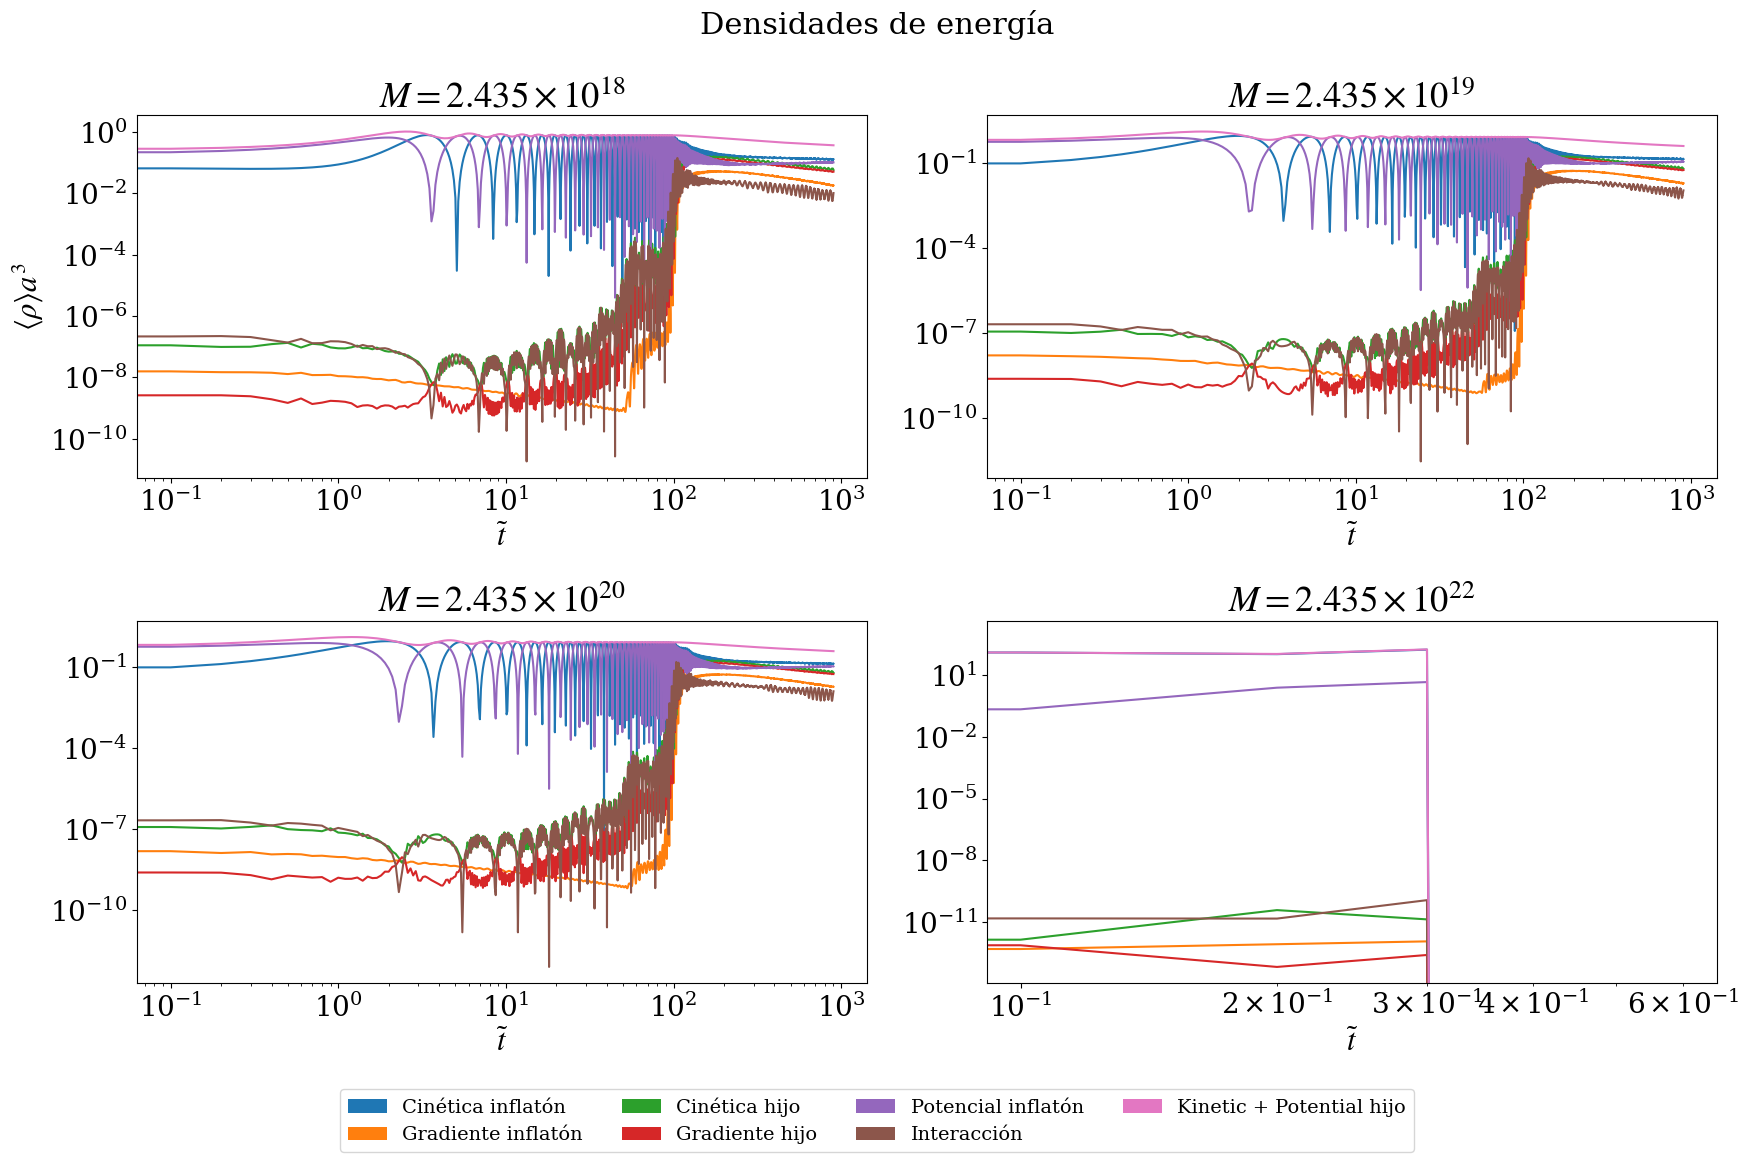

In [11]:
from matplotlib.patches import Patch

enDat_tanh2_m1 = np.loadtxt(dir_tanh2_m1 + "average_energies.txt")
enDat_tanh2_m2 = np.loadtxt(dir_tanh2_m2 + "average_energies.txt")
enDat_tanh2_m3 = np.loadtxt(dir_tanh2_m3 + "average_energies.txt")
enDat_tanh2_m4 = np.loadtxt(dir_tanh2_m4 + "average_energies.txt")

def plot_combined_models_case(enDat, aDat, q_val_labels):
    
    # Etiquetas de las componentes y colores
    labels = ["Cinética inflatón", "Gradiente inflatón", "Cinética hijo", "Gradiente hijo", 
              "Potencial inflatón", "Interacción", "Kinetic + Potential hijo"]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]
    
    fig = plt.figure(figsize=(18, 12))
    
    for idx in range(4):
        row, col = divmod(idx, 2)
        ax = plt.subplot2grid((2, 2), (row, col))
        enDat_i = enDat[idx]
        aDat_i = aDat[idx]
        for comp in range(1, enDat_i.shape[1]):
            ax.plot(enDat_i[:,0], enDat_i[:,comp] * aDat_i[:,1]**3, color=colors[comp-1])
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_title(fr"{q_val_labels[idx]}")
        ax.set_xlabel(r"$\tilde{t}$")
        if idx == 0: ax.set_ylabel(r"$\langle \rho \rangle a^3$")

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    # Leyenda general
    legend_elements = [Patch(facecolor=colors[i], label=labels[i]) for i in range(len(labels))]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=4, fontsize=14)

    plt.suptitle(fr"Densidades de energía", fontsize=22)
    plt.show()

# Llamada para el caso m1
plot_combined_models_case([enDat_tanh2_m1, enDat_tanh2_m2, enDat_tanh2_m3, enDat_tanh2_m4], [aDat_tanh2_m1, aDat_tanh2_m2, aDat_tanh2_m3, aDat_tanh2_m4], q_labels)

# Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [12]:
def load_spectrum(filename, comment='#'):
    """Función para cargar los espectros manejando los saltos de línea de CosmoLattice."""
    with open(filename, 'r') as file:
        nBins = 0
        line = file.readline()
        while line and line != "\n":
            if line[0] != comment:
                nBins += 1
            line = file.readline()
    
    fileSp = np.loadtxt(filename, comments=comment)
    nSpectra = len(fileSp) // nBins
    return fileSp, int(nBins), int(nSpectra)

def plot_spectrum_into_ax(ax, spectra, column, nBins, nSpectra, ylabel, colormap='plasma'):
    """Dibuja el espectro en un eje específico con una barra de color."""
    colors = plt.get_cmap(colormap)
    # Ajustamos el normalizador para que coincida con el tiempo de la simulación si es necesario
    norm = plt.Normalize(vmin=0, vmax=nSpectra-1)
    
    for i in range(nSpectra):
        ax.plot(
            spectra[i*nBins:(i+1)*nBins, 0],
            spectra[i*nBins:(i+1)*nBins, column],
            color=colors(i / nSpectra),
            alpha=0.8
        )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\tilde{k}$', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    
    # Barra de color individual para cada subplot
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'$t$', fontsize=12)

def plot_combined_spectra(field_num, dirs, q_val_labels, column=1):
    """
    field_num: 0 para inflatón, 1 para campo hijo.
    column: 1 para Espectro (Delta), 2 para Número de ocupación (nk).
    """
    field_name = "inflatón" if field_num == 0 else "hijo"
    quantity = "Espectro" if column == 1 else "Número de ocupación"
    ylabel = (r'$\tilde{\Delta}_{\tilde{\phi}}$' if field_num == 0 else r'$\tilde{\Delta}_{\tilde{\chi}}$') if column == 1 else (r'$\tilde{n}_{\tilde{\phi}}$' if field_num == 0 else r'$\tilde{n}_{\tilde{\chi}}$')
    
    filename = f"spectra_scalar_{field_num}.txt"
    fig = plt.figure(figsize=(18, 12))
    
    for idx in range(4):
        row, col = divmod(idx, 2)
        ax = plt.subplot2grid((2, 2), (row, col))
        path = os.path.join(dirs[idx], filename)
        if os.path.exists(path):
            sp, nBins, nSpec = load_spectrum(path)
            plot_spectrum_into_ax(ax, sp, column, nBins, nSpec, ylabel)
        ax.set_title(fr"{q_val_labels[idx]}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(fr"{quantity} del campo {field_name}", fontsize=22)
    plt.show()

## Inflaton

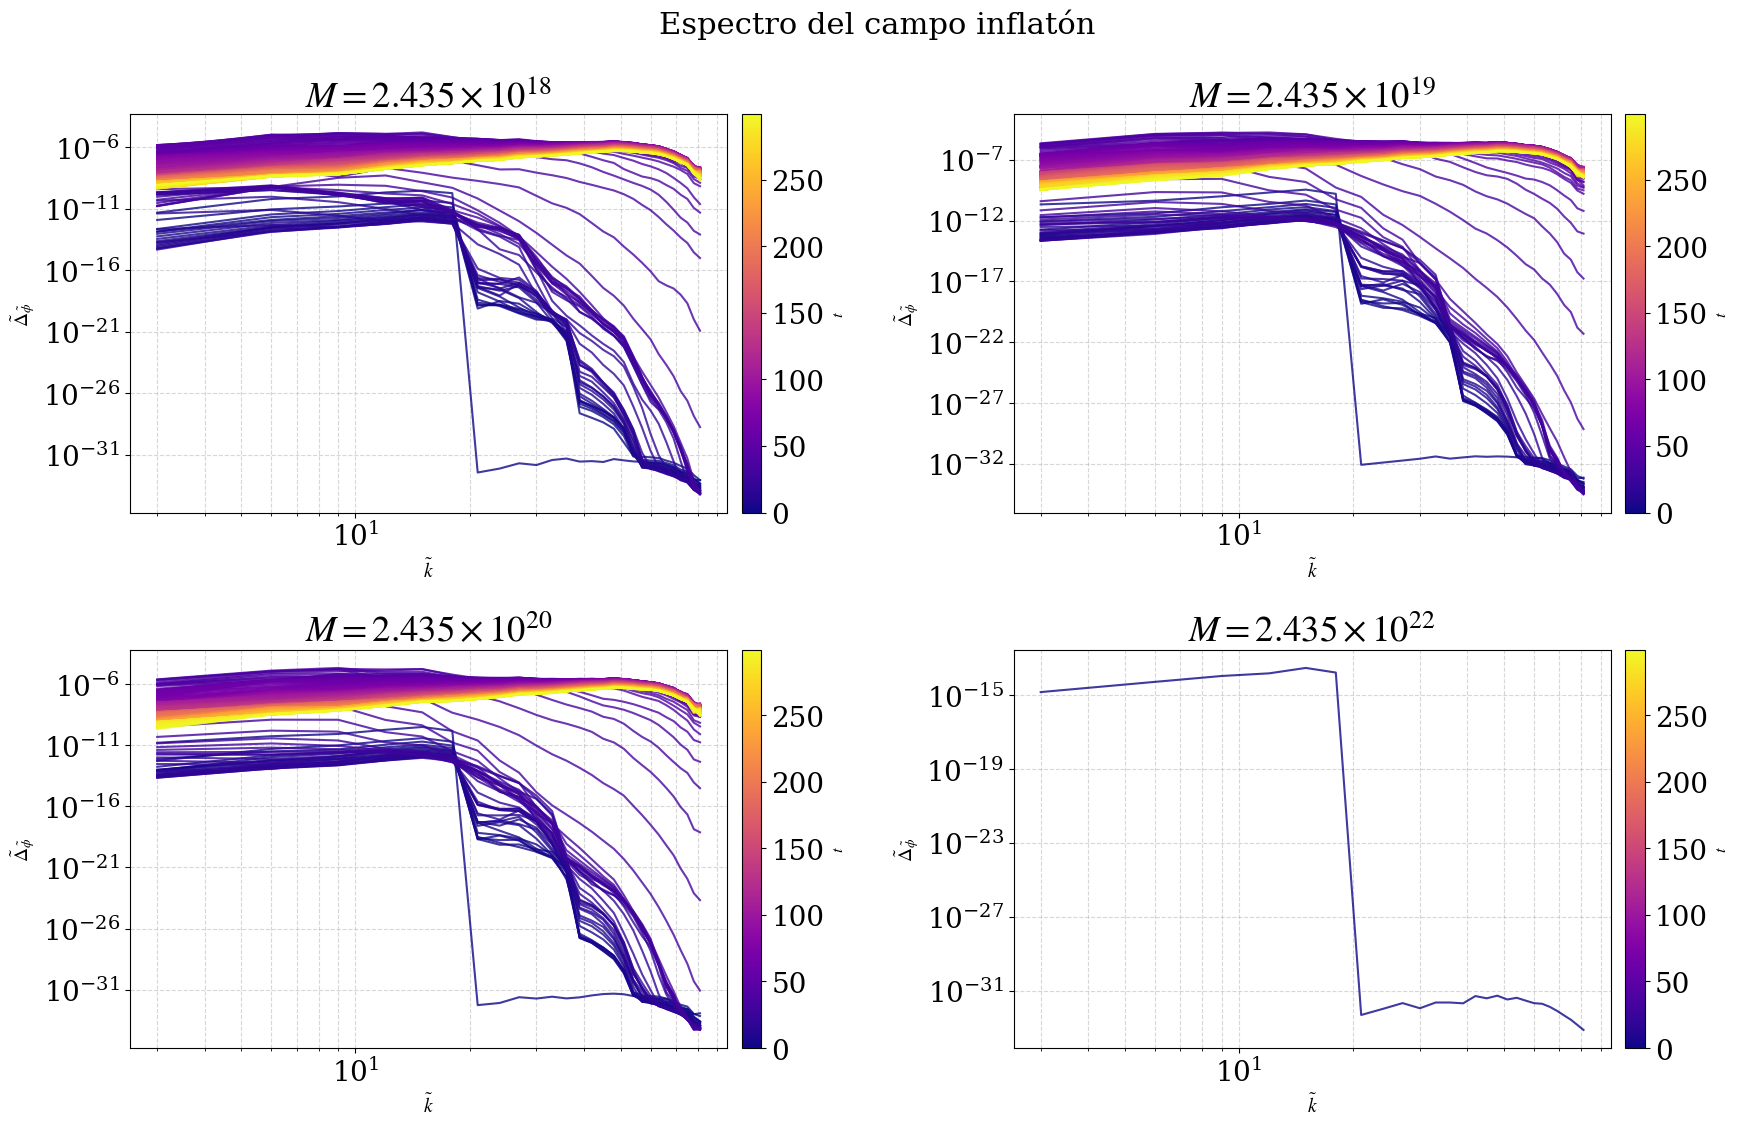

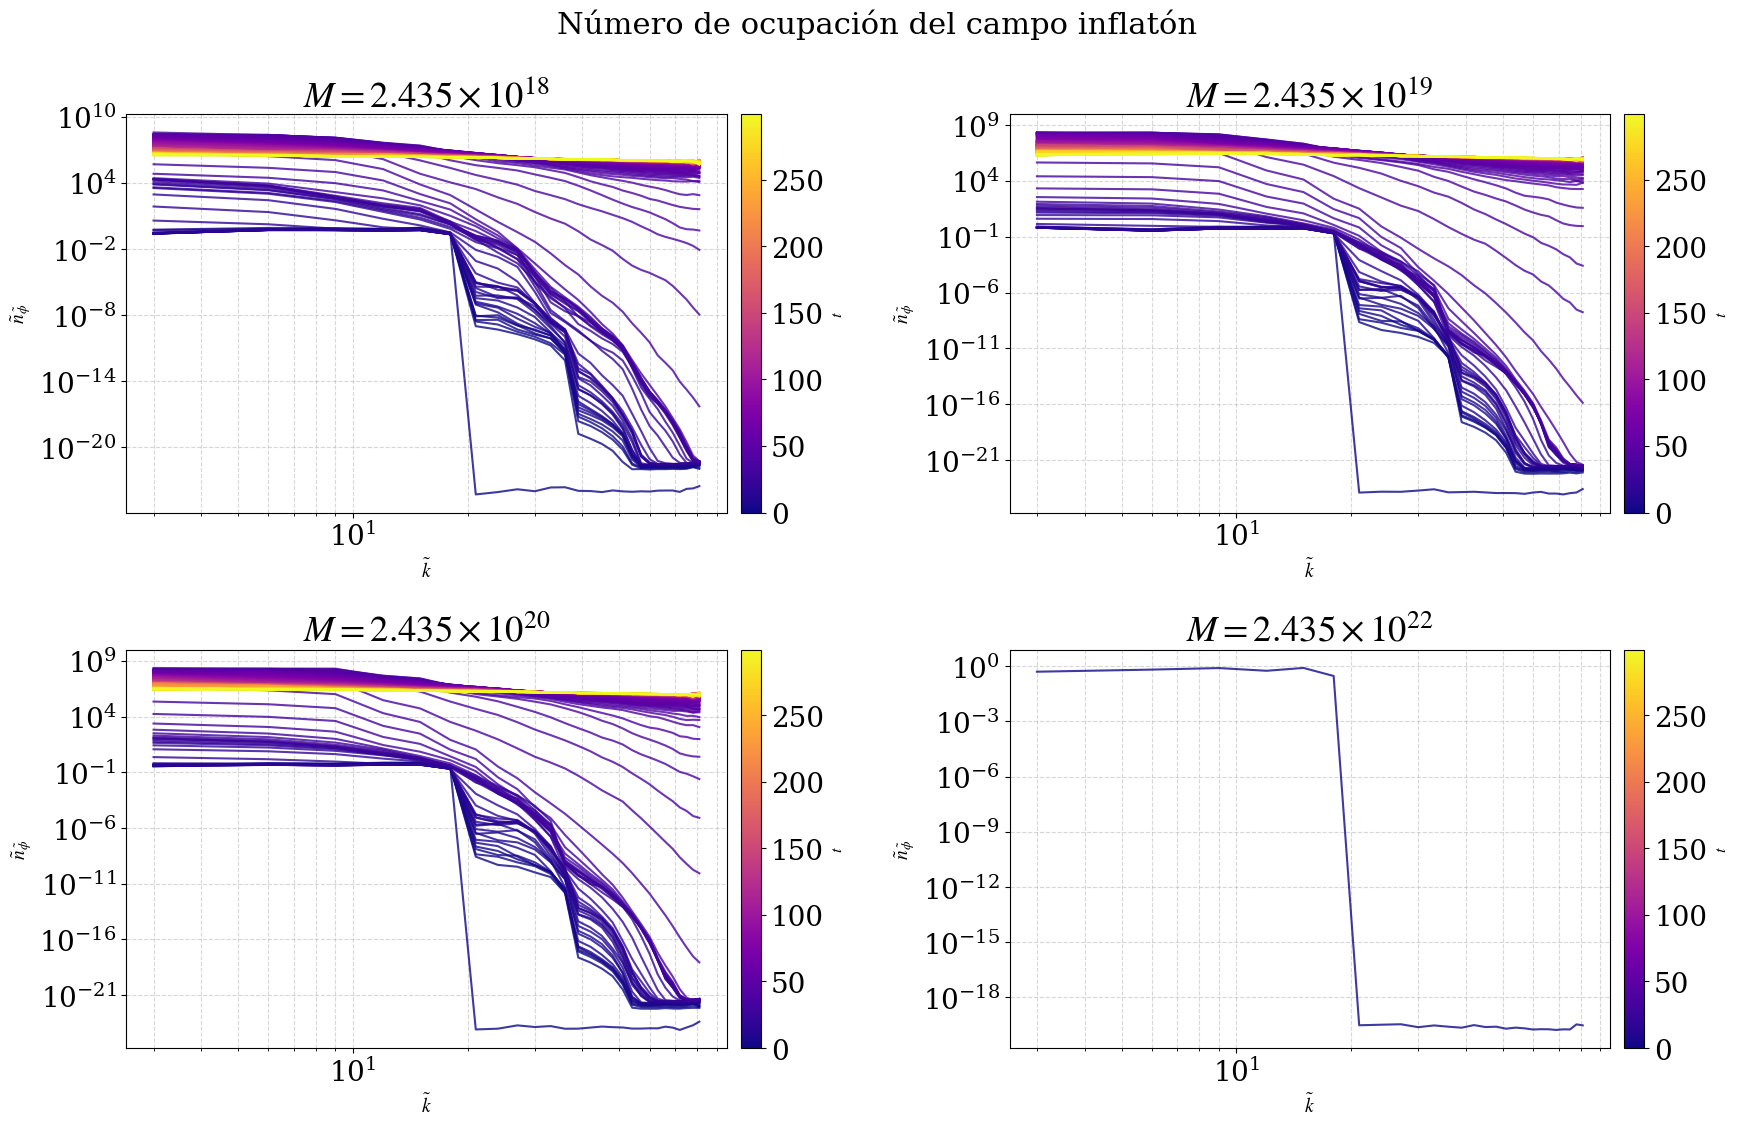

In [13]:
plot_combined_spectra(0,[dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], q_labels, column=1)

plot_combined_spectra(0,[dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], q_labels, column=3)

## Daughter field

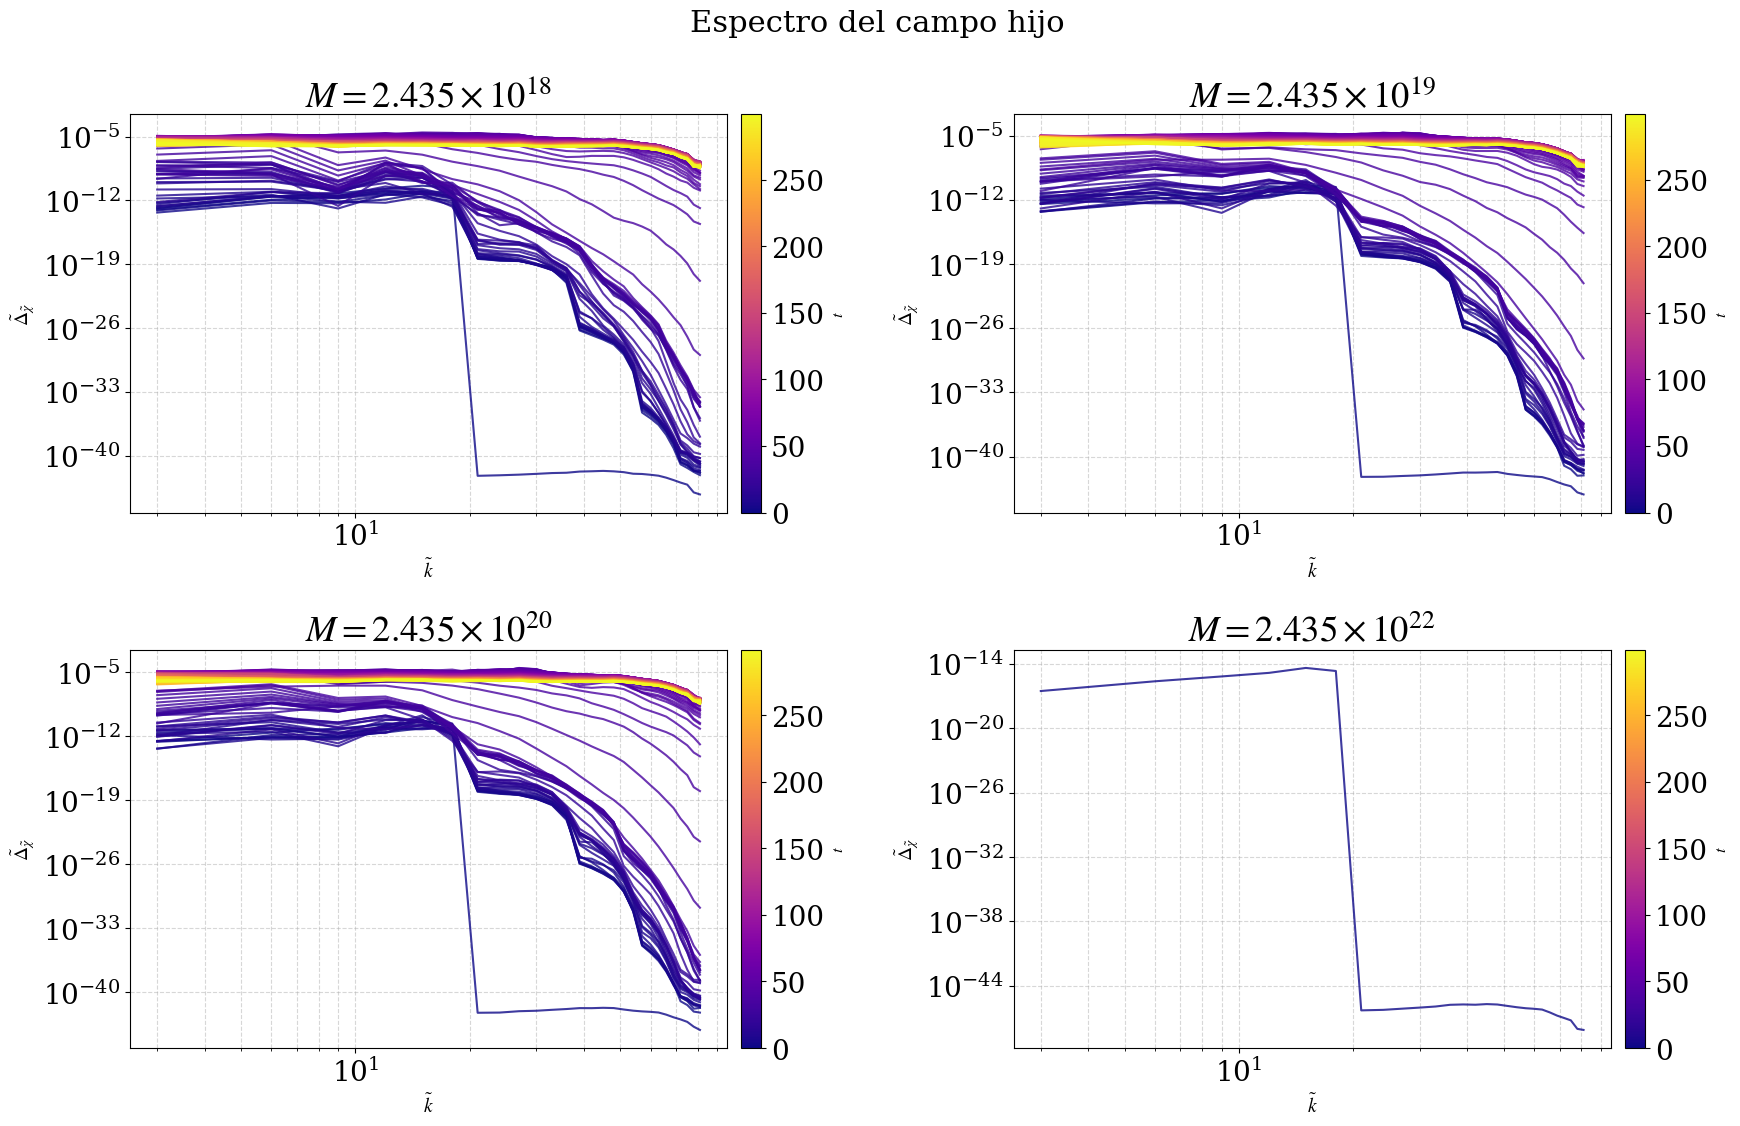

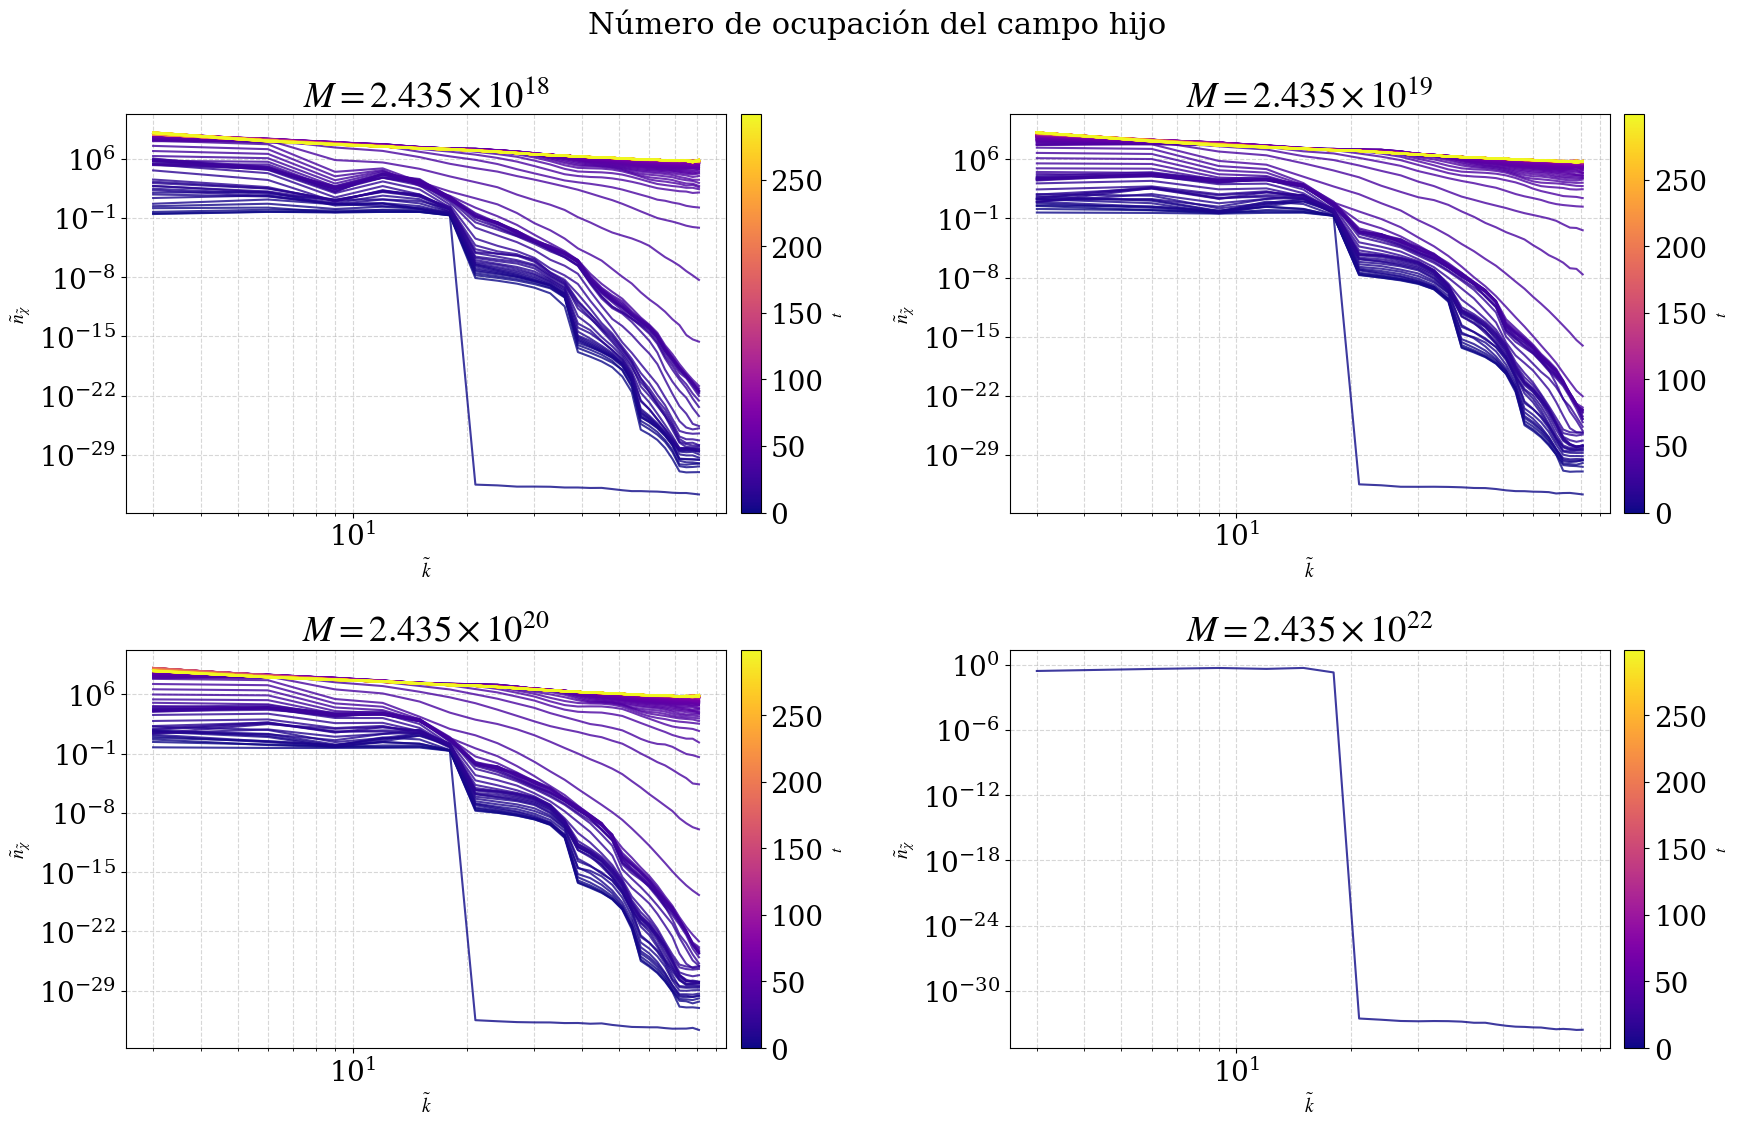

In [14]:
plot_combined_spectra(1,[dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], q_labels, column=1)

plot_combined_spectra(1,[dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], q_labels, column=3)

# GWs

In [15]:
def load_gws(filename, comment='#'):
    """Carga los espectros de GWs manejando los saltos de línea."""
    with open(filename, 'r') as file:
        nBins = 0
        line = file.readline()
        while line and line != "\n":
            if line[0] != comment:
                nBins += 1
            line = file.readline()
    
    fileSp = np.loadtxt(filename, comments=comment)
    nSpectra = len(fileSp) // nBins
    return fileSp, int(nBins), int(nSpectra)

def plot_gw_into_ax(ax, gw_data, nBins, nSpectra, ylabel=r'$\tilde{\Delta}_h$', colormap='viridis'):
    """Dibuja el espectro de GWs en un eje específico."""
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=nSpectra-1)
    
    for i in range(nSpectra):
        ax.plot(
            gw_data[i*nBins:(i+1)*nBins, 0],
            gw_data[i*nBins:(i+1)*nBins, 1], # La columna 1 suele ser el espectro de potencia
            color=colors(i / nSpectra),
            alpha=0.8
        )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\tilde{k}$', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'$t$', fontsize=12)

def plot_combined_gws_case(dirs, q_val_labels):
    
    filename = "spectra_gws.txt"
    fig = plt.figure(figsize=(18, 12))
    ylabel = r'$\tilde{\Delta}_h$'
    
    for i in range(4):
        row, col = divmod(i, 2)
        ax = plt.subplot2grid((2, 2), (row, col))
        path = os.path.join(dirs[i], filename)
        if os.path.exists(path):
            sp, nBins, nSpec = load_gws(path)
            plot_gw_into_ax(ax, sp, nBins, nSpec, ylabel, colormap='plasma')
        ax.set_title(fr"{q_val_labels[i]}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(fr"Espectro de Ondas Gravitacionales", fontsize=22)
    plt.show()

/tmp/ipykernel_94975/3652413763.py:28: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


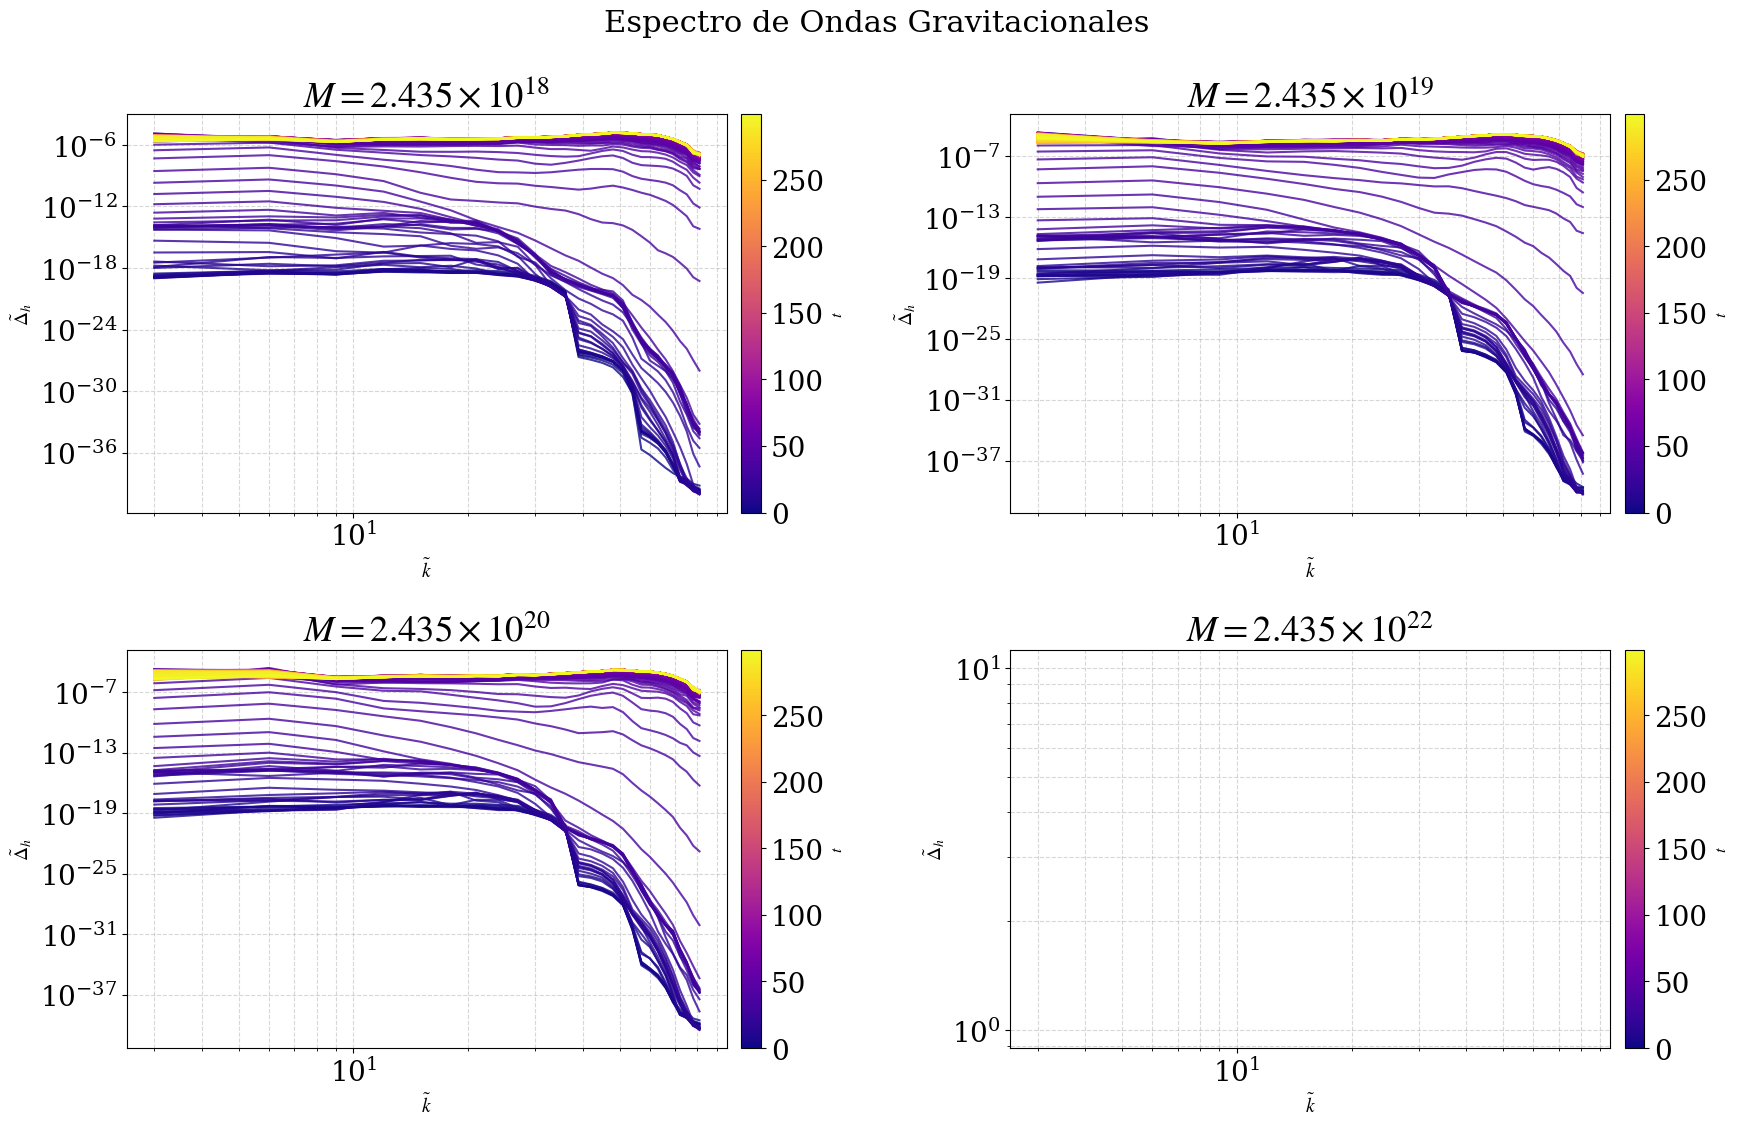

In [16]:
plot_combined_gws_case([dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], q_labels)

/tmp/ipykernel_94975/262272264.py:16: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


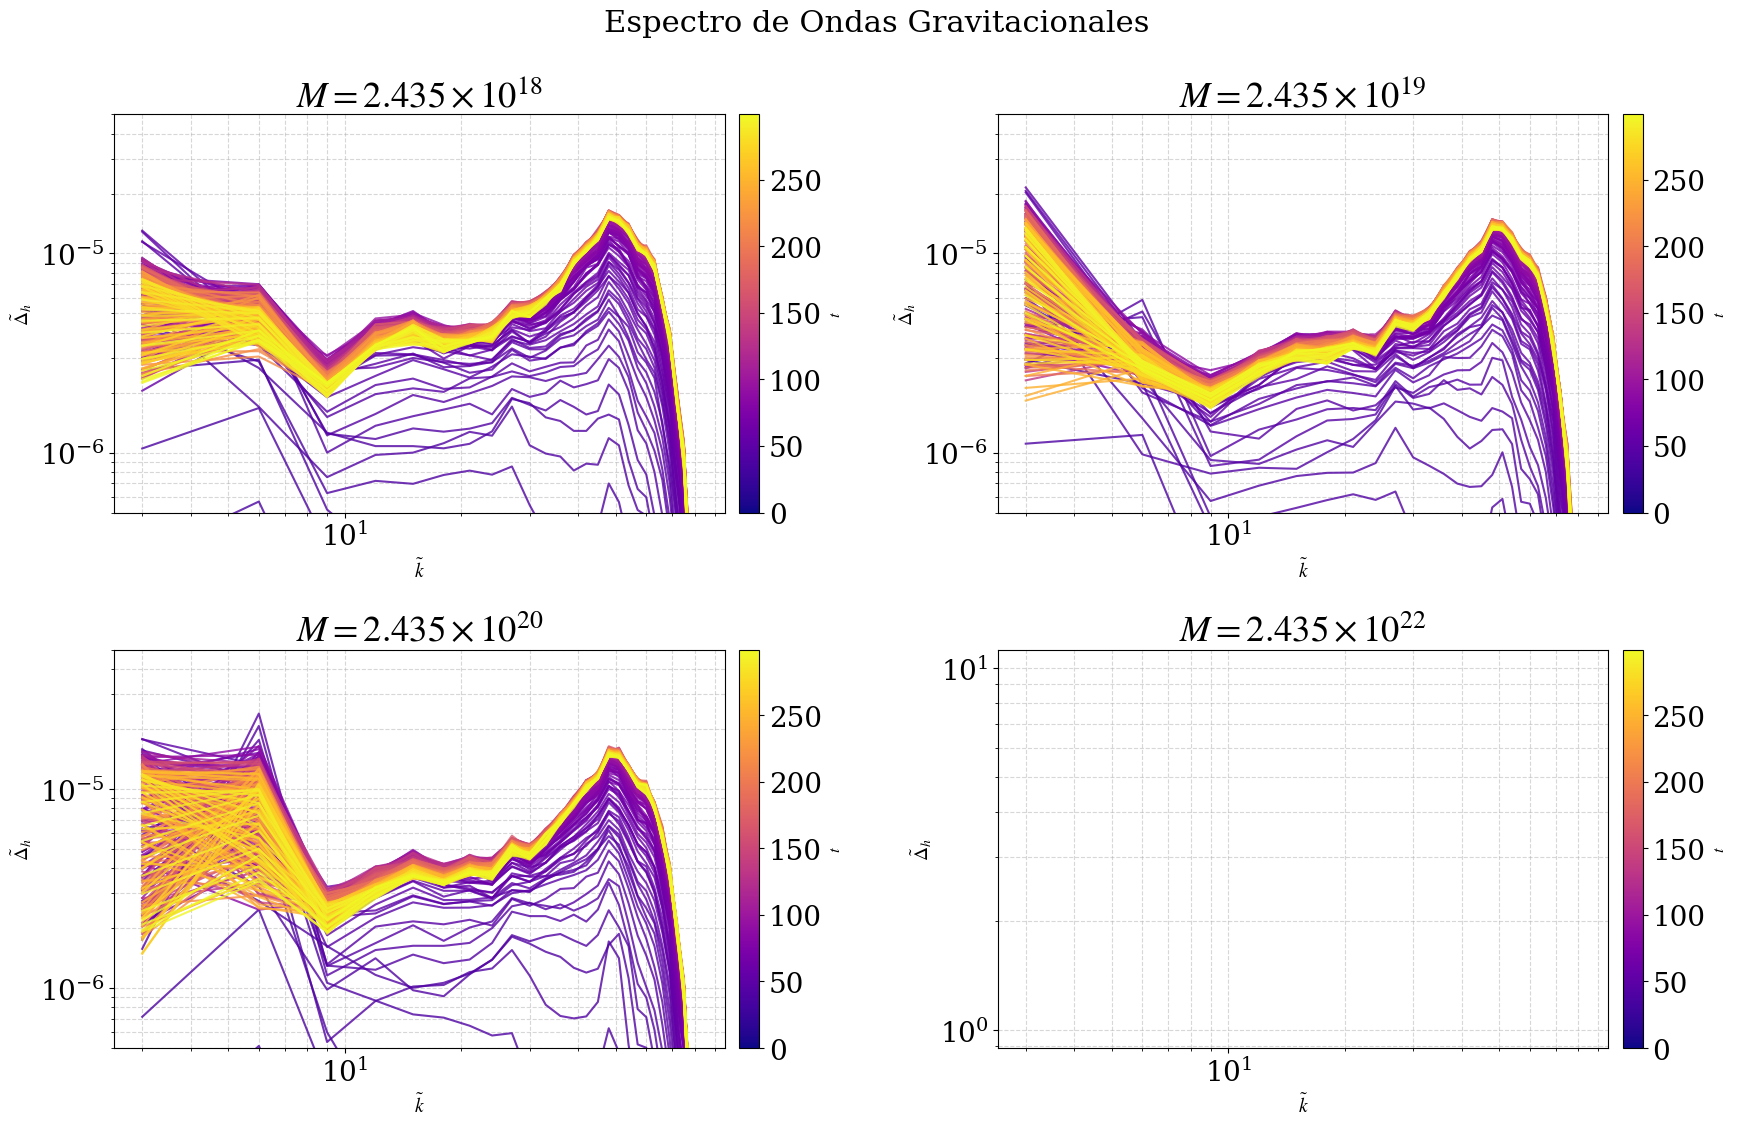

In [17]:
def plot_gw_into_ax(ax, gw_data, nBins, nSpectra, ylabel=r'$\tilde{\Delta}_h$', colormap='viridis', auto_zoom=True):
    """Dibuja el espectro de GWs en un eje específico con zoom dinámico inteligente."""
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=nSpectra-1)
    
    # 1. Graficar las curvas
    for i in range(nSpectra):
        ax.plot(
            gw_data[i*nBins:(i+1)*nBins, 0],
            gw_data[i*nBins:(i+1)*nBins, 1], 
            color=colors(i / nSpectra),
            alpha=0.8
        )
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\tilde{k}$', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    
    # --- LÓGICA DE ZOOM DINÁMICO ---
    if auto_zoom:
        # Extraemos la columna de amplitudes (columna 1) y filtramos valores > 0
        y_vals = gw_data[:, 1]
        pos_vals = y_vals[y_vals > 0]
        
        if len(pos_vals) > 0:
            max_val = np.nanmax(pos_vals)
            
            # Obtenemos el exponente base (orden de magnitud)
            expo = np.floor(np.log10(max_val))
            orden = 10**expo
            
            # REGLA DE TECHO FLEXIBLE:
            # Si el valor máximo real es mayor a 5 * orden, ponemos el límite en 10.
            # Esto evita que los picos queden fuera del gráfico.
            if max_val > 5 * orden:
                y_top = 10 * orden
            else:
                y_top = 5 * orden
            
            # El límite inferior son 2 órdenes de magnitud menos que el superior
            y_bottom = y_top / 100
            
            # Aplicar límites al objeto ax
            ax.set_ylim(y_bottom, y_top)
    # -------------------------------
    
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'$t$', fontsize=12)

plot_combined_gws_case([dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], q_labels)

## Energía de las GWs

In [18]:
def integrate_gw_spectrum(gw_data, nBins, nSpectra):
    """
    Integra el espectro de GWs para cada tiempo de salida.
    Utiliza la regla del trapecio sobre los datos del espectro.
    """
    total_energy = []
    for i in range(nSpectra):
        # Seleccionamos el bloque del espectro para el tiempo i
        # Columna 0: k_tilde, Columna 1: Delta_h
        k = gw_data[i*nBins:(i+1)*nBins, 0]
        delta_h = gw_data[i*nBins:(i+1)*nBins, 1]
        
        # Integración numérica
        energy = np.trapezoid(delta_h, k)
        total_energy.append(energy)
    return np.array(total_energy)

def plot_combined_gw_energies(dirs, q_val_labels):
    """
    Gráfica la evolución temporal de la energía total de las GWs.
    """
    filename = "spectra_gws.txt"
    fig = plt.figure(figsize=(18, 12))
    
    for i in range(4):
        row, col = divmod(i, 2)
        ax = plt.subplot2grid((2, 2), (row, col))
        path = os.path.join(dirs[i], filename)
        if os.path.exists(path):
            sp, nBins, nSpec = load_gws(path) # Usamos la función load_gws definida antes
            e_gw = integrate_gw_spectrum(sp, nBins, nSpec)
            # El eje x es el índice del espectro (o tiempo proporcional)
            ax.plot(np.arange(nSpec), e_gw, color='tab:red', lw=2)
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_title(fr"{q_val_labels[i]}")
        ax.set_xlabel(r"Índice de espectro ($t$)")
        if i == 0: ax.set_ylabel(r"$E_{GW}$ (Integrada)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(fr"Evolución de la Energía de GWs", fontsize=22)
    plt.show()

/tmp/ipykernel_94975/1465636498.py:34: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')
/tmp/ipykernel_94975/1465636498.py:35: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale('log')


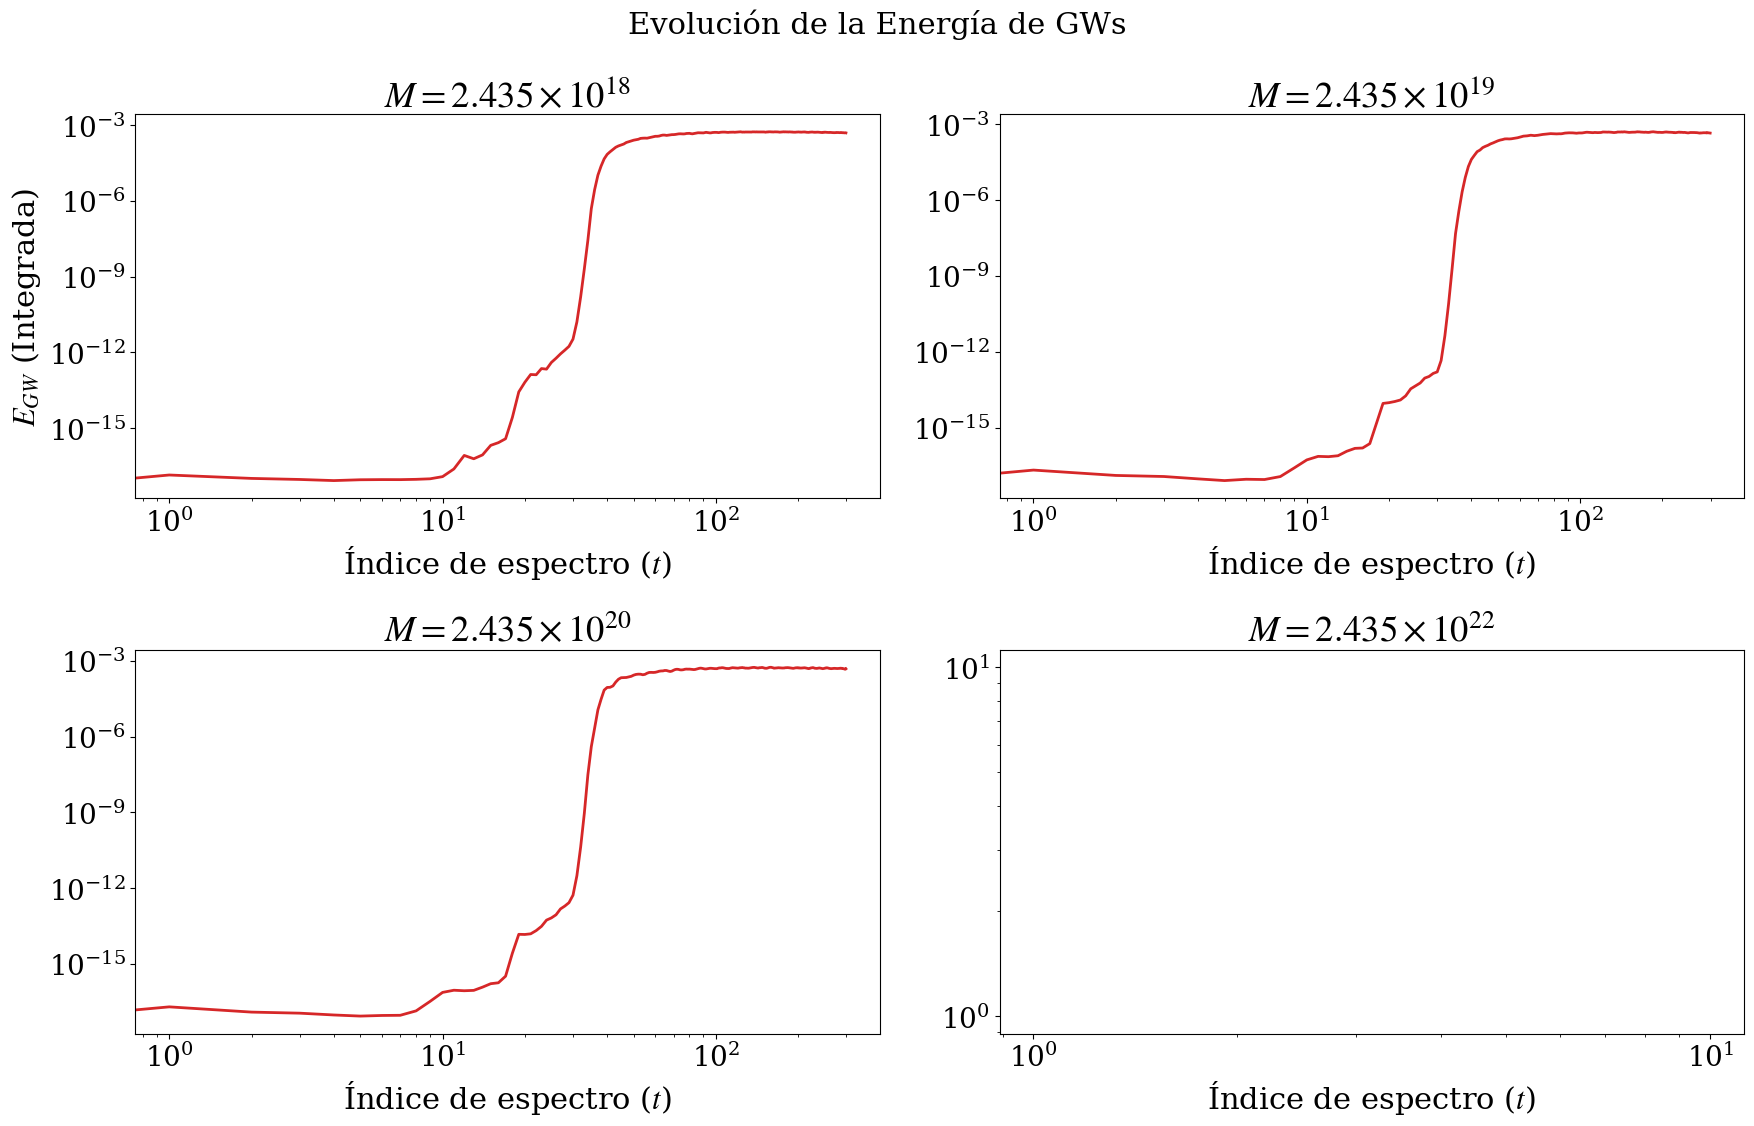

In [19]:
plot_combined_gw_energies([dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], q_labels)

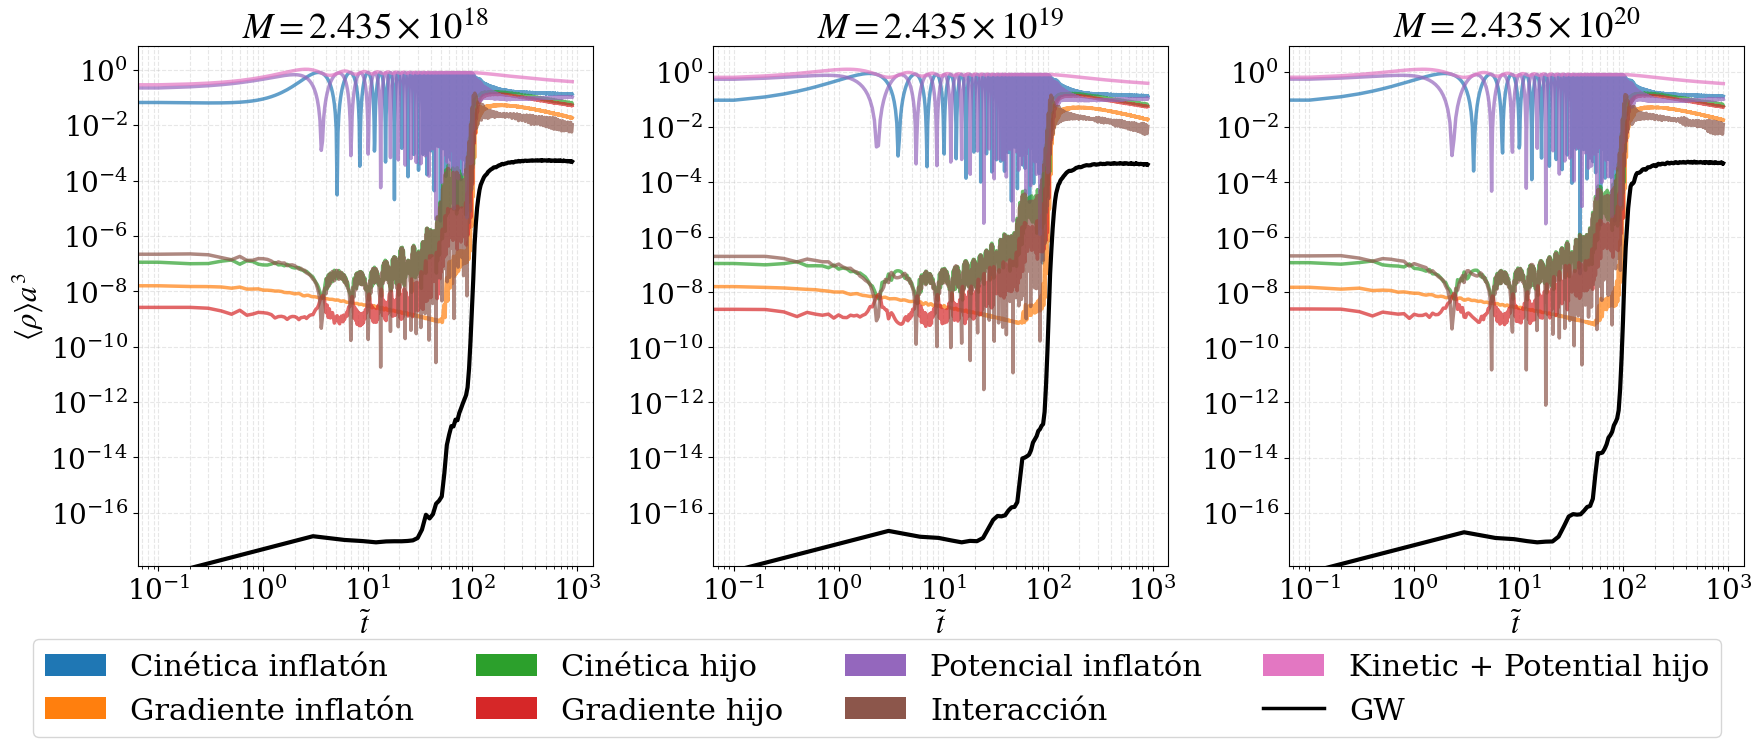

In [20]:
def plot_combined_total_energies(dir, aDat, m_val_labels):
    
    labels = ["Cinética inflatón", "Gradiente inflatón", "Cinética hijo", "Gradiente hijo", 
              "Potencial inflatón", "Interacción", "Kinetic + Potential hijo", "GW"]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "black"]
    
    fig = plt.figure(figsize=(18, 8))
    
    def plot_densities_and_gw(ax, dir_path, aDat, title):
        # 1. Cargar y graficar densidades de los campos
        en_path = os.path.join(dir_path, "average_energies.txt")
        if os.path.exists(en_path):
            enDat = np.loadtxt(en_path)
            nCols = enDat.shape[1]
            for col in range(1, nCols):
                ax.plot(enDat[:,0], enDat[:,col] * aDat[:,1]**3, color=colors[col-1], alpha=0.7, lw = 2.5)
        
        # 2. Cargar, integrar y graficar GWs
        gw_path = os.path.join(dir_path, "spectra_gws.txt")
        if os.path.exists(gw_path):
            # Usamos las funciones de carga y integración definidas previamente
            sp, nBins, nSpec = load_gws(gw_path)
            e_gw = integrate_gw_spectrum(sp, nBins, nSpec)
            # El factor '3' suele ser el intervalo de tiempo entre salidas de espectros
            ax.plot(np.arange(nSpec)*3, e_gw, color='black', lw=3, label='GW')
        
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_title(title)
        ax.set_xlabel(r"$\tilde{t}$")
        ax.grid(True, which='both', ls='--', alpha=0.3)

    for i in range(3):
        row, col = divmod(i, 3)
        ax = plt.subplot2grid((1, 3), (row, col))
        plot_densities_and_gw(ax, dir[i], aDat[i], fr"{m_val_labels[i]}")
        if i == 0: ax.set_ylabel(r"$\langle \rho \rangle a^3$")
        #if i == 0 or i == 2: ax.set_ylabel(r"$\langle \rho \rangle a^3$")
        #if i == 3: ax.set_xticks([1e-2, 1e-1, 1e0, 1e1, 1e2])

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    # Leyenda única con el agregado de GW
    legend_elements = [Patch(facecolor=colors[i], label=labels[i]) for i in range(len(labels)-1)]
    legend_elements.append(plt.Line2D([0], [0], color='black', lw=2.5, label='GW'))
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=22)
    #plt.show()
    plt.savefig("energy_tanh2_varM.pdf", format='pdf', bbox_inches='tight')

m_labels = q_labels

plot_combined_total_energies([dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], [aDat_tanh2_m1, aDat_tanh2_m2, aDat_tanh2_m3, aDat_tanh2_m4], m_labels)

In [21]:
def analyze_scale_transitions(t_data, E_data):
    """
    Identifica transiciones entre órdenes de magnitud en los datos de energía.
    Filtra automáticamente valores no válidos (≤ 0 o NaN).
    """
    # Asegurar que sean arrays de numpy y del tipo correcto
    E_data = np.asarray(E_data, dtype=float)
    t_data = np.asarray(t_data, dtype=float)
    
    # Máscara para filtrar valores válidos
    valid_mask = (E_data > 0) & np.isfinite(E_data) & np.isfinite(t_data)
    valid_indices = np.where(valid_mask)[0] # Índices originales de los datos válidos
    
    if len(valid_indices) == 0:
        print("ERROR: No hay valores válidos para analizar")
        return None
    
    E_valid = E_data[valid_indices]
    t_valid = t_data[valid_indices]
    
    # Calcular órdenes de magnitud
    magnitudes = np.floor(np.log10(E_valid))
    min_magnitude = int(magnitudes.min())
    max_magnitude = int(magnitudes.max())
    
    # Agrupar los índices locales según su orden de magnitud
    idx_min_mag_group = np.where(magnitudes == min_magnitude)[0]
    idx_max_mag_group = np.where(magnitudes == max_magnitude)[0]
    
    # Encontrar el MÁXIMO dentro de la magnitud MÍNIMA
    local_max_in_min = np.argmax(E_valid[idx_min_mag_group])
    idx_max_in_min = valid_indices[idx_min_mag_group[local_max_in_min]] # Mapeo al índice original
    
    # Encontrar el MÍNIMO dentro de la magnitud MÁXIMA
    local_min_in_max = np.argmin(E_valid[idx_max_mag_group])
    idx_min_in_max = valid_indices[idx_max_mag_group[local_min_in_max]] # Mapeo al índice original
    
    return {
        'min_magnitude': min_magnitude,
        'max_magnitude': max_magnitude,
        'idx_max_in_min': idx_max_in_min,
        't_max_in_min': t_data[idx_max_in_min],
        'E_max_in_min': E_data[idx_max_in_min],
        'idx_min_in_max': idx_min_in_max,
        't_min_in_max': t_data[idx_min_in_max],
        'E_min_in_max': E_data[idx_min_in_max],
        'n_valid': len(valid_indices),
        'n_total': len(E_data),
    }

def plot_scale_transitions(t_data, E_data, analysis, ax=None):
    """
    Genera el gráfico de las transiciones. Permite inyectar un eje (ax) 
    para integrarlo fácilmente en subplots de Matplotlib.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6)) # Usa el figsize por defecto de tu notebook
        
    ax.plot(t_data, E_data, 'o-', markersize=6, label='Datos', color='black', linewidth=1.5, zorder=3)

    # Extraer variables para legibilidad
    idx1, t1, E1, mag_min = analysis['idx_max_in_min'], analysis['t_max_in_min'], analysis['E_max_in_min'], analysis['min_magnitude']
    idx2, t2, E2, mag_max = analysis['idx_min_in_max'], analysis['t_min_in_max'], analysis['E_min_in_max'], analysis['max_magnitude']

    # Marcar puntos clave usando strings crudos (fr"") para mejor compatibilidad con tu fuente 'stix'
    ax.plot(t1, E1, 's', markersize=12, 
             label=fr"Máx en $10^{{{mag_min}}}$: $t={t1:.1f}$", 
             color='blue', zorder=4, markeredgecolor='darkblue', markeredgewidth=1.5)

    ax.plot(t2, E2, 's', markersize=12, 
             label=fr"Mín en $10^{{{mag_max}}}$: $t={t2:.1f}$", 
             color='red', zorder=4, markeredgecolor='darkred', markeredgewidth=1.5)

    # Líneas horizontales de órdenes de magnitud
    ax.axhline(10**mag_min, color='blue', linestyle='--', lw=1.5, alpha=0.5, label=fr"$10^{{{mag_min}}}$ (menor escala)")
    ax.axhline(10**(mag_min+1), color='blue', linestyle='--', lw=1.5, alpha=0.2)

    ax.axhline(10**mag_max, color='red', linestyle='--', lw=1.5, alpha=0.5, label=fr"$10^{{{mag_max}}}$ (mayor escala)")
    ax.axhline(10**(mag_max+1), color='red', linestyle='--', lw=1.5, alpha=0.2)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'$t$', fontsize=16)
    ax.set_ylabel(r'$E_{GW}$', fontsize=16)
    ax.set_title('Transiciones entre órdenes de magnitud', fontsize=16)
    ax.legend(fontsize=12, loc='best')
    ax.grid(True, which="both", ls="--", alpha=0.3)
    
    if ax is None:
        plt.tight_layout()
        plt.show()
        
    return ax

def plot_combined_gw_energies_with_transitions(dirs, q_val_labels, time_step=1.0, print_reports=False):
    """
    Gráfica la evolución temporal de la energía total de las GWs y
    analiza las transiciones de escala para cada directorio en una grilla.
    Retorna una lista con los índices de los mínimos en la mayor escala (puntos rojos).
    """
    filename = "spectra_gws.txt"
    fig = plt.figure(figsize=(18, 12))
    
    indices_puntos_rojos = [] # Inicializamos la lista
    
    for i in range(len(dirs)):
        row, col = divmod(i, 2)
        ax = plt.subplot2grid((2, 2), (row, col))
        path = os.path.join(dirs[i], filename)
        
        if os.path.exists(path):
            # 1. Cargar e integrar datos
            sp, nBins, nSpec = load_gws(path) # Asegurate de tener load_gws definida
            e_gw = integrate_gw_spectrum(sp, nBins, nSpec)
            
            # Definir el eje de tiempo
            t_gw = np.arange(nSpec) * time_step
            
            # 2. Analizar transiciones
            analysis = analyze_scale_transitions(t_gw, e_gw)
            
            # 3. Graficar y guardar índice
            if analysis is not None:
                plot_scale_transitions(t_gw, e_gw, analysis, ax=ax)
                
                indices_puntos_rojos.append(analysis['idx_min_in_max']) # Guardamos el índice
                
                if print_reports:
                    print(f"\n{'='*70}\nDirectorio: {q_val_labels[i]}")
                    print(f"Magnitud mínima: {analysis['min_magnitude']}, Magnitud máxima: {analysis['max_magnitude']}")
                    print(f"Máximo en escala mínima: t={analysis['t_max_in_min']:.1f}, E={analysis['E_max_in_min']:.2e}")
                    print(f"Mínimo en escala máxima: t={analysis['t_min_in_max']:.1f}, E={analysis['E_min_in_max']:.2e}")
                    print(f"Valores válidos: {analysis['n_valid']}/{analysis['n_total']}")
            else:
                ax.plot(t_gw, e_gw, color='tab:red', lw=2)
                ax.set_yscale('log')
                ax.set_xscale('log')
                indices_puntos_rojos.append(None) # Guardamos None si falla
        else:
            indices_puntos_rojos.append(None) # Guardamos None si no hay archivo

        # 4. Ajustes estéticos para la grilla
        ax.set_title(fr"{q_val_labels[i]}", fontsize=16)
        ax.set_xlabel(r"Tiempo ($t$)")
        
        if col == 0: 
            ax.set_ylabel(r"$E_{GW}$ (Integrada)", fontsize=16)
        else:
            ax.set_ylabel("")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(fr"Evolución de la Energía de GWs y Transiciones", fontsize=22)
    plt.show()
    
    return indices_puntos_rojos

ERROR: No hay valores válidos para analizar


/tmp/ipykernel_94975/1282480937.py:136: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')
/tmp/ipykernel_94975/1282480937.py:137: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale('log')


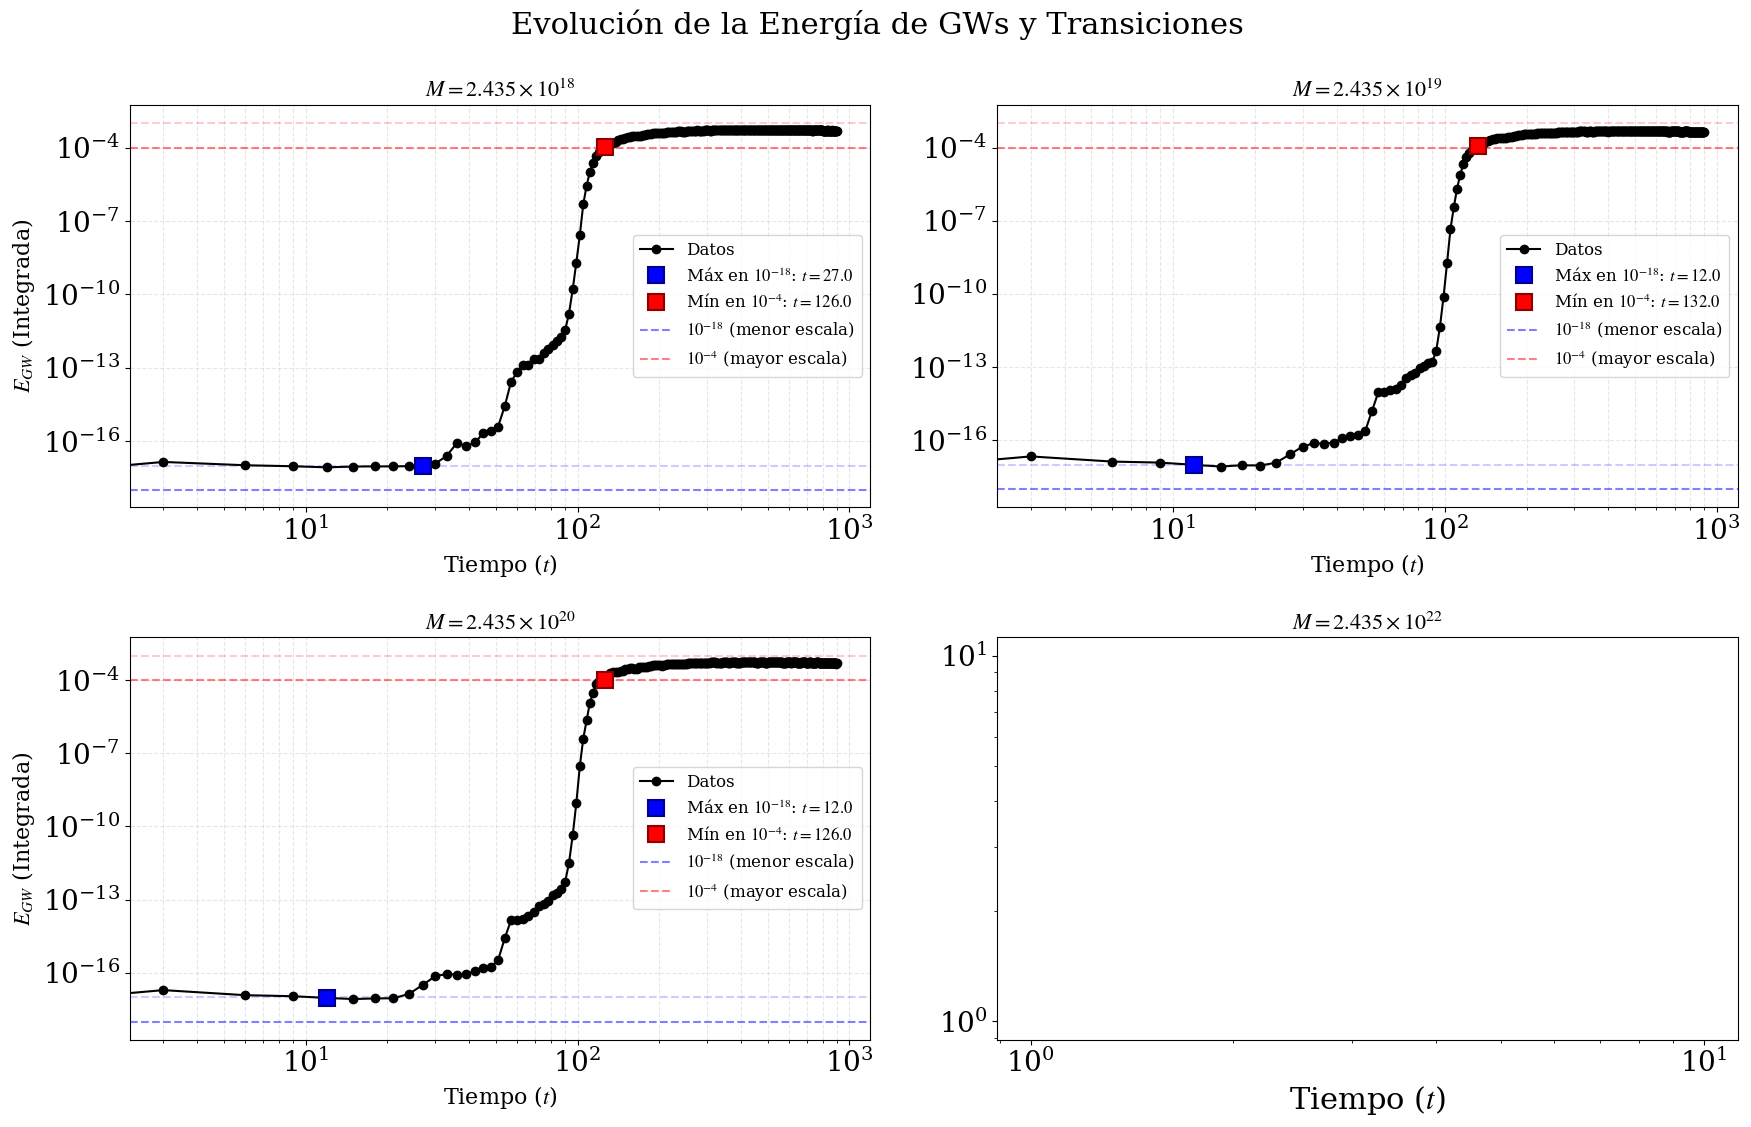


Índices de los puntos rojos extraídos:
[np.int64(42) np.int64(44) np.int64(42) None]


In [22]:
lista_rojos = plot_combined_gw_energies_with_transitions(
    [dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], 
    m_labels,
    time_step=3.0, 
    print_reports=False
)
print("\nÍndices de los puntos rojos extraídos:")
print(np.array(lista_rojos))

In [23]:
def plot_full_rescaled_gw_spectra_grid(dirs, q_val_labels, red_dot_indices):
    """
    Grafica la evolución completa de los espectros reescalados en una grilla de 4x2.
    El índice del 'punto rojo' se utiliza ÚNICAMENTE para extraer a_f y calcular
    los factores de conversión al momento actual.
    """
    # --- Constantes físicas y del modelo ---
    Omega_RAD = 8.6e-5
    greh = 106.5
    g0 = 3.36
    gs0 = 3.91
    gsreh = 106.5
    kB = 8.617333e-14                        # GeV/K
    h = 4.134e-24                            # GeV*s
    Treh = 1e14                              # GeV
    T0 = 2.726 * kB                          # GeV
    omega = 0                                # RAD
    m = 1.46e13
    phi0 = 3.44e18
    fStar = phi0
    
    # Nombres de los archivos
    filename_sp = "spectra_gws.txt"
    filename_a = "average_scale_factor.txt"
    filename_en = "average_energies.txt"

    fig = plt.figure(figsize=(18, 12))
    
    for i in range(len(dirs)):
        row, col = divmod(i, 2)
        ax = plt.subplot2grid((2, 2), (row, col))
        
        path_sp = os.path.join(dirs[i], filename_sp)
        path_a = os.path.join(dirs[i], filename_a)
        path_en = os.path.join(dirs[i], filename_en)
        
        idx_red = red_dot_indices[i] 
        
        if os.path.exists(path_sp) and os.path.exists(path_a) and os.path.exists(path_en) and idx_red is not None:
            # 1. Carga de datos
            sp, nBins, nSpec = load_spectrum(path_sp) 
            aDat = np.loadtxt(path_a)
            enDat = np.loadtxt(path_en)
            
            # 2. Parámetros dependientes de la simulación
            omegaStar = m
            
            ai = aDat[0, 1]           
            af = aDat[idx_red, 1]  # <--- Usamos el punto rojo SOLO para fijar a_f
            Vi = enDat[0, 5] * (fStar**2 * omegaStar**2)
            
            # 3. Escaleos físicos fijos para este directorio
            f0 = omegaStar/(2 * np.pi * h) * (gs0/gsreh) * (np.pi**2*greh/(60*Vi))**(1/(3*(1+omega))) * T0 * Treh**((1 - 3*omega)/(3*(1+omega)))
            Omega0 = Omega_RAD * greh/g0 * (gs0/gsreh)**(4/3) * (np.pi**2 * greh * Treh**4/(60*Vi))**((1 - 3*omega)/(3*(1+omega))) * (af/ai)**(1 - 3*omega)
            
            # 4. Configuración del Colormap (basado en tu plot_spectrum_today)
            colors = plt.get_cmap('plasma')
            # Asumo pasos de tiempo proporcionales a 3 como en tu notebook, cambialo si es necesario
            norm = plt.Normalize(vmin=0, vmax=(nSpec-1)*3) 
            sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
            sm.set_array([])
            
            # 5. Iterar sobre TODO el espectro y graficar
            for j in range(nSpec):
                k_tilde = sp[j*nBins:(j+1)*nBins, 0]
                delta_h = sp[j*nBins:(j+1)*nBins, 1]
                
                f_Hz = k_tilde * f0
                Omega_GW_0 = delta_h * Omega0
                
                ax.plot(f_Hz, Omega_GW_0, color=colors(j/nSpec), lw=1.5, alpha=0.8)
            
            ax.set_yscale('log')
            ax.set_xscale('log')
            
            # 6. Agregamos la barra de colores por cada subplot
            cbar = plt.colorbar(sm, ax=ax, pad=0.02)
            cbar.set_label(r'$t$', fontsize=14, rotation=0, labelpad=10)
            cbar.ax.tick_params(labelsize=10)
            
        ax.set_title(fr"{q_val_labels[i]}", fontsize=16)
        ax.set_xlabel(r'$f_0$ [Hz]', fontsize=14)
        
        if col == 0: 
            ax.set_ylabel(r'$\tilde\Omega_{GW} (f_0, t_0)$', fontsize=16)
        ax.grid(True, which="both", ls="--", alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.show()
    plt.savefig("Omega_tanh2_varM.pdf", format='pdf', bbox_inches='tight')

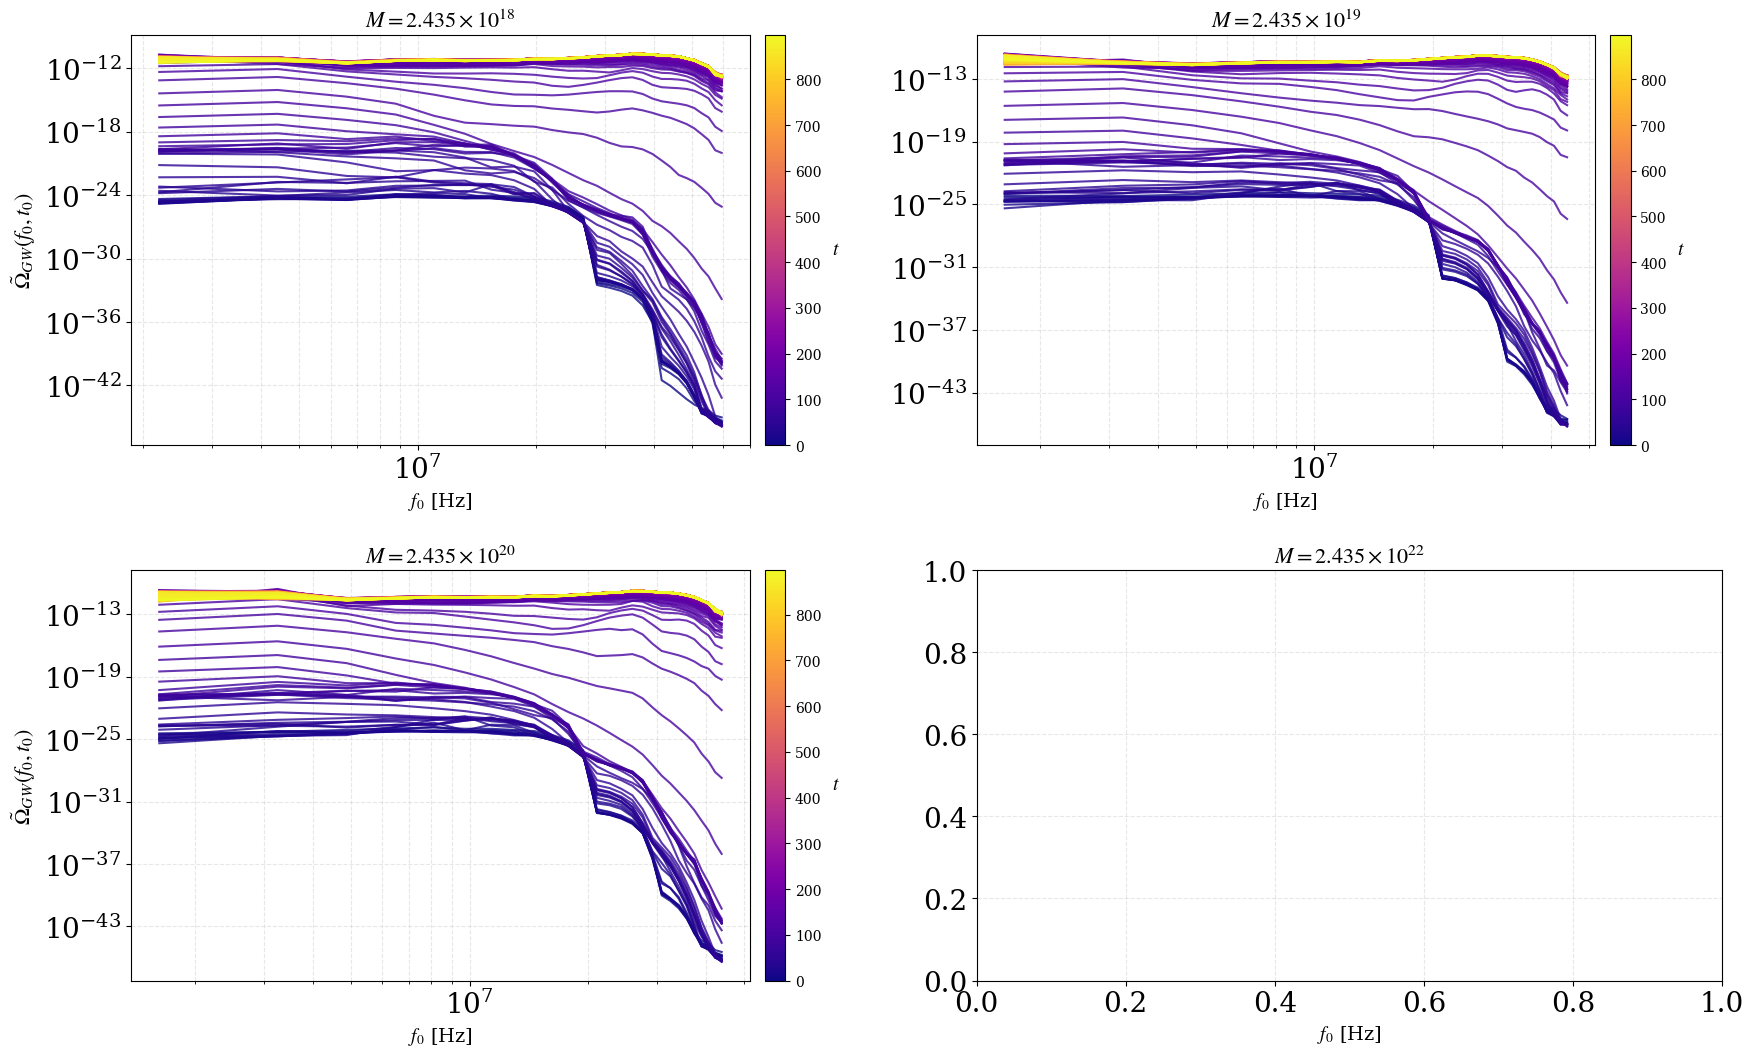

In [24]:
plot_full_rescaled_gw_spectra_grid(
    dirs=[dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], 
    q_val_labels=m_labels, 
    red_dot_indices=lista_rojos
)

In [25]:
def plot_full_rescaled_gw_spectra_grid(dirs, q_val_labels, red_dot_indices, ms):
    """
    Grafica la evolución completa de los espectros reescalados en una grilla de 4x2.
    El índice del 'punto rojo' se utiliza ÚNICAMENTE para extraer a_f y calcular
    los factores de conversión al momento actual.
    """
    # --- Constantes físicas y del modelo ---
    Omega_RAD = 8.6e-5
    greh = 106.5
    g0 = 3.36
    gs0 = 3.91
    gsreh = 106.5
    kB = 8.617333e-14                        # GeV/K
    h = 4.134e-24                            # GeV*s
    Treh = 1e14                              # GeV
    T0 = 2.726 * kB                          # GeV
    omega = 0                                # RAD
    phi0 = 3.44e18
    fStar = phi0
    
    # Nombres de los archivos
    filename_sp = "spectra_gws.txt"
    filename_a = "average_scale_factor.txt"
    filename_en = "average_energies.txt"

    fig = plt.figure(figsize=(18, 6))
    
    for i in range(len(dirs)):
        row, col = divmod(i, 3)
        ax = plt.subplot2grid((1, 3), (row, col))
        
        path_sp = os.path.join(dirs[i], filename_sp)
        path_a = os.path.join(dirs[i], filename_a)
        path_en = os.path.join(dirs[i], filename_en)
        
        idx_red = red_dot_indices[i] 
        
        if os.path.exists(path_sp) and os.path.exists(path_a) and os.path.exists(path_en) and idx_red is not None:
            # 1. Carga de datos
            sp, nBins, nSpec = load_spectrum(path_sp) 
            aDat = np.loadtxt(path_a)
            enDat = np.loadtxt(path_en)
            
            # 2. Parámetros dependientes de la simulación
            omegaStar = ms[i]
            
            ai = aDat[0, 1]           
            af = aDat[idx_red, 1]  # <--- Usamos el punto rojo SOLO para fijar a_f
            Vi = enDat[0, 5] * (fStar**2 * omegaStar**2)
            
            # 3. Escaleos físicos fijos para este directorio
            f0 = omegaStar/(2 * np.pi * h) * (gs0/gsreh) * (np.pi**2*greh/(60*Vi))**(1/(3*(1+omega))) * T0 * Treh**((1 - 3*omega)/(3*(1+omega)))
            Omega0 = Omega_RAD * greh/g0 * (gs0/gsreh)**(4/3) * (np.pi**2 * greh * Treh**4/(60*Vi))**((1 - 3*omega)/(3*(1+omega))) * (af/ai)**(1 - 3*omega)
            
            
            # --- Lógica de Auto-Zoom Blindada ---
            # Extraemos el último espectro para fijar límites visuales
            last_delta_h = sp[(nSpec-1)*nBins : nSpec*nBins, 1]
            last_Omega_GW = last_delta_h * Omega0
            
            # Filtro para evitar log(0) o NaN por ruido numérico
            valid_idx = (last_Omega_GW > 0) & (np.isfinite(last_Omega_GW))
            
            if np.any(valid_idx):
                actual_values = last_Omega_GW[valid_idx]
                y_max = np.max(actual_values)
                y_min = y_max / 1e2  # Zoom de 6 órdenes de magnitud
            else:
                y_min, y_max = 1e-25, 1e-10 # Fallback
            
            # 4. Configuración del Colormap
            colors = plt.get_cmap('plasma')
            norm = plt.Normalize(vmin=0, vmax=(nSpec-1)*3) 
            sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
            sm.set_array([])
            
            # 5. Graficar evolución temporal
            for j in range(nSpec):
                k_tilde = sp[j*nBins:(j+1)*nBins, 0]
                delta_h = sp[j*nBins:(j+1)*nBins, 1]
                
                f_Hz = k_tilde * f0
                Omega_GW_0 = delta_h * Omega0
                
                ax.plot(f_Hz, Omega_GW_0, color=colors(j/nSpec), lw=1.5, alpha=0.8)
            
            ax.set_yscale('log')
            ax.set_xscale('log')
            ax.set_ylim(y_min, y_max * 10) # Margen superior para los picos
            
            cbar = plt.colorbar(sm, ax=ax, pad=0.02)
            cbar.set_label(r'$t$', fontsize=24, rotation=0, labelpad=20)
            
        ax.set_title(fr"{q_val_labels[i]}")
        ax.set_xlabel(r'$f_0$ [Hz]')
        
        if col == 0: 
            ax.set_ylabel(r'$\tilde\Omega_{GW} (f_0)$')
        ax.grid(True, which="both", ls="--", alpha=0.8)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.show()
    plt.savefig("Omega_tanh2_varM.pdf", format='pdf', bbox_inches='tight')

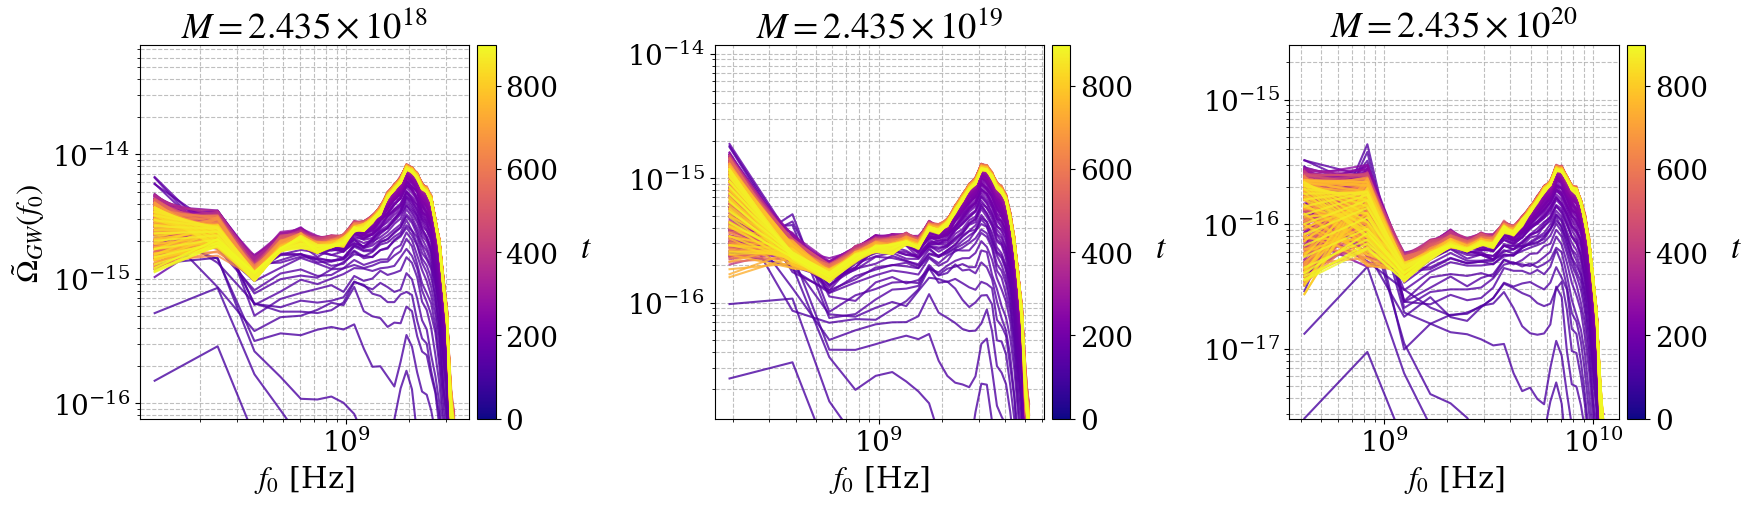

In [26]:
plot_full_rescaled_gw_spectra_grid(
    dirs=[dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3], 
    q_val_labels=m_labels, 
    red_dot_indices=lista_rojos,
    ms=[2.435e18, 2.435e19, 2.435e20] 
)

In [27]:
def plot_full_rescaled_h_spectra_grid(dirs, q_val_labels, red_dot_indices, ms):
    """
    Grafica la evolución completa de los espectros reescalados en una grilla de 2x2.
    El índice del 'punto rojo' se utiliza ÚNICAMENTE para extraer a_f y calcular
    los factores de conversión al momento actual.
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    # --- Constantes físicas y del modelo ---
    Omega_RAD = 8.6e-5
    greh = 106.5
    g0 = 3.36
    gs0 = 3.91
    gsreh = 106.5
    kB = 8.617333e-14                        # GeV/K
    h = 4.134e-24                            # GeV*s
    Treh = 1e14                              # GeV
    T0 = 2.726 * kB                          # GeV
    omega = 0                                # RAD
    phi0 = 3.44e18
    fStar = phi0
    
    # Nombres de los archivos
    filename_sp = "spectra_gws.txt"
    filename_a = "average_scale_factor.txt"
    filename_en = "average_energies.txt"
    
    fig = plt.figure(figsize=(18, 12)) # Un poco más ancho para que entren bien las colorbars
    n_rows, n_cols = 2, 2
    for i in range(len(dirs)):
        row, col = divmod(i, n_cols)
        ax = plt.subplot2grid((n_rows, n_cols), (row, col))
        
        path_sp = os.path.join(dirs[i], filename_sp)
        path_a = os.path.join(dirs[i], filename_a)
        path_en = os.path.join(dirs[i], filename_en)
        
        idx_red = red_dot_indices[i] 
        
        if os.path.exists(path_sp) and os.path.exists(path_a) and os.path.exists(path_en) and idx_red is not None:
            # 1. Carga de datos
            sp, nBins, nSpec = load_spectrum(path_sp) 
            aDat = np.loadtxt(path_a)
            enDat = np.loadtxt(path_en)
            
            # 2. Parámetros dependientes de la simulación
            omegaStar = ms[i]
            
            ai = aDat[0, 1]           
            af = aDat[idx_red, 1]  # <--- Usamos el punto rojo SOLO para fijar a_f
            Vi = enDat[0, 5] * (fStar**2 * omegaStar**2)
            
            # 3. Escaleos físicos fijos para este directorio
            f0 = omegaStar/(2 * np.pi * h) * (gs0/gsreh) * (np.pi**2*greh/(60*Vi))**(1/(3*(1+omega))) * T0 * Treh**((1 - 3*omega)/(3*(1+omega)))
            Omega0 = Omega_RAD * greh/g0 * (gs0/gsreh)**(4/3) * (np.pi**2 * greh * Treh**4/(60*Vi))**((1 - 3*omega)/(3*(1+omega))) * (af/ai)**(1 - 3*omega)
            
            # 4. Configuración del Colormap (basado en tu plot_spectrum_today)
            colors = plt.get_cmap('plasma')
            norm = plt.Normalize(vmin=0, vmax=(nSpec-1)*3) 
            sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
            sm.set_array([])
            
            # 5. Iterar sobre TODO el espectro y graficar
            for j in range(nSpec):
                k_tilde = sp[j*nBins:(j+1)*nBins, 0]
                delta_h = sp[j*nBins:(j+1)*nBins, 1]
                
                H0 = 2.3e-18 #Hz
                f_Hz = k_tilde * f0
                Omega_GW_0 = delta_h * Omega0
                hc = np.sqrt(Omega_GW_0) / (f_Hz / H0) * np.sqrt(3)/np.pi
                ax.plot(f_Hz, hc, color=colors(j/nSpec), lw=1.5, alpha=0.8)
            
            ax.set_yscale('log')
            ax.set_xscale('log')
            
            # 6. Agregamos la barra de colores por cada subplot
            cbar = plt.colorbar(sm, ax=ax, pad=0.02)
            cbar.set_label(r'$t$', fontsize=14, rotation=0, labelpad=10)
            cbar.ax.tick_params(labelsize=10)
        
        ax.set_title(fr"{q_val_labels[i]}", fontsize=16)
        ax.set_xlabel(r'$f_0$ [Hz]', fontsize=14)
        
        if col == 0: 
            ax.set_ylabel(r'$h_c (f_0, t_0)$', fontsize=16)
        ax.grid(True, which="both", ls="--", alpha=0.3)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

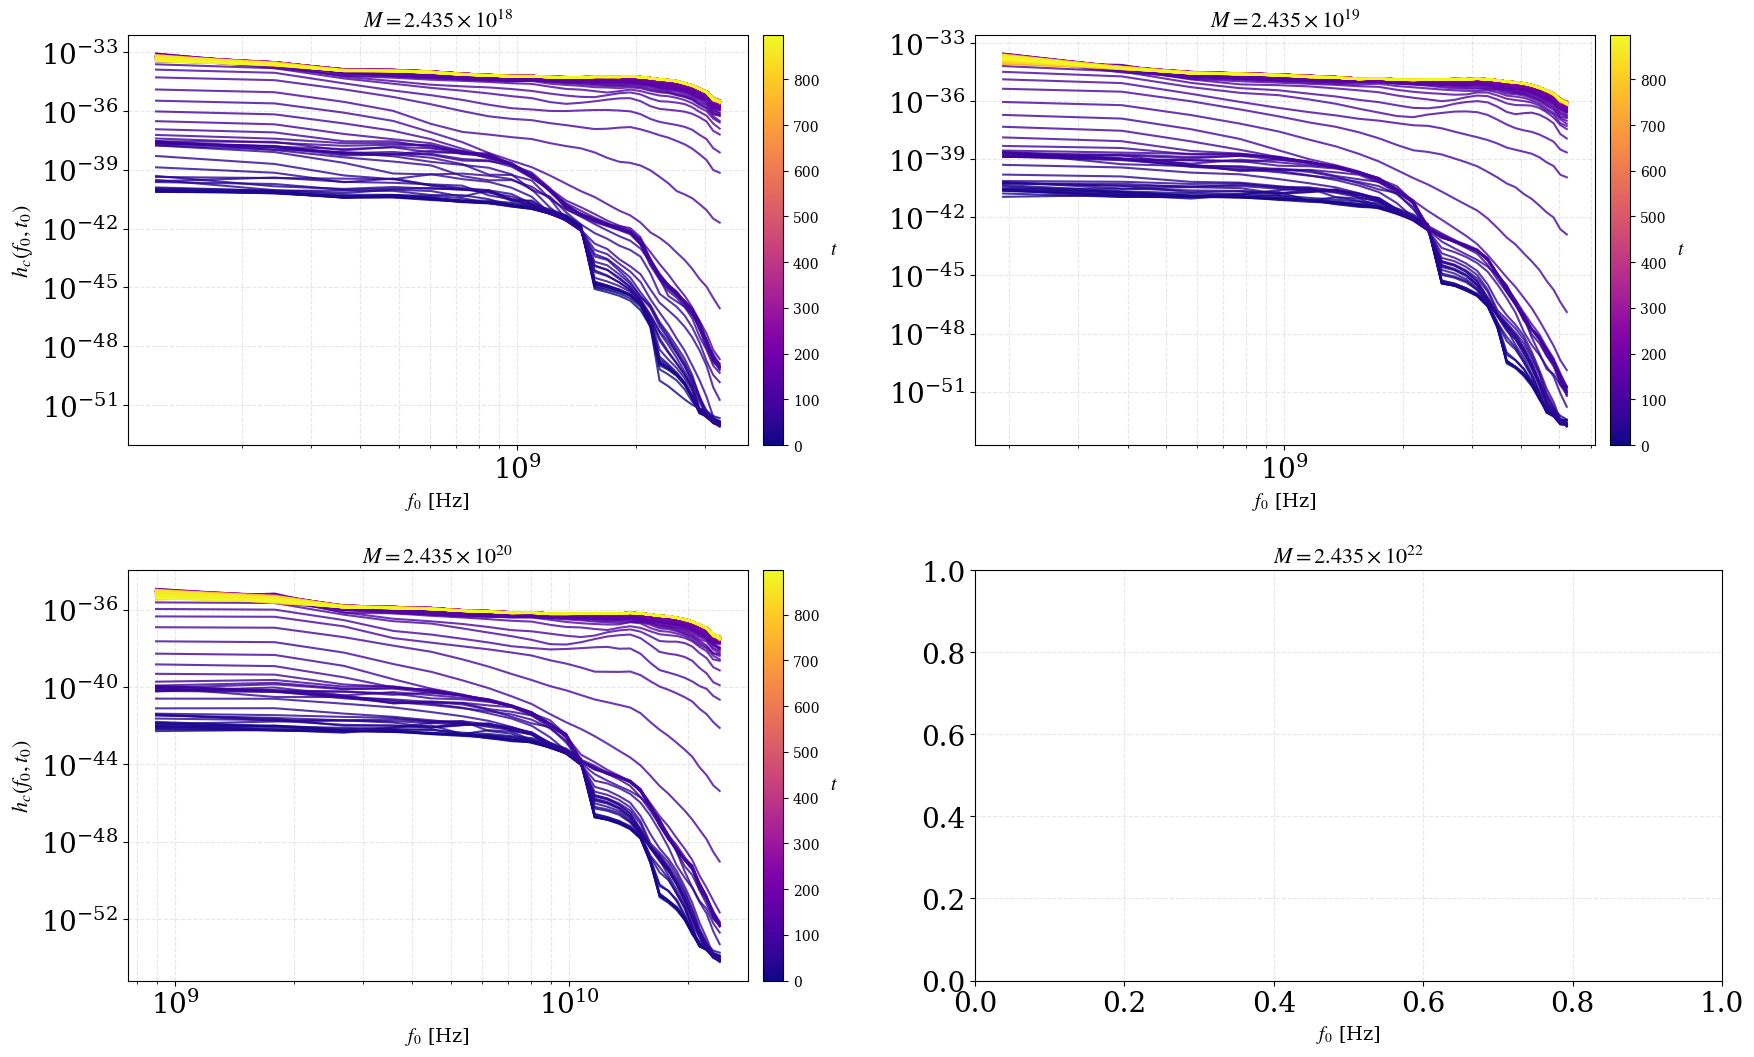

In [28]:
plot_full_rescaled_h_spectra_grid(
    dirs=[dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], 
    q_val_labels=m_labels, 
    red_dot_indices=lista_rojos, 
    ms = [2.435e18, 2.435e19, 2.435e21, 2.435e22]
)

In [29]:
def plot_full_rescaled_h_spectra_grid(dirs, q_val_labels, red_dot_indices, ms):
    """
    Grafica la evolución completa de la amplitud característica h_c reescalada
    en una grilla de 5x3 con auto-zoom blindado.
    """
    # --- Constantes físicas y del modelo ---
    Omega_RAD = 8.6e-5
    greh = 106.5
    g0 = 3.36
    gs0 = 3.91
    gsreh = 106.5
    kB = 8.617333e-14                        # GeV/K
    h = 4.134e-24                            # GeV*s
    Treh = 1e14                              # GeV
    T0 = 2.726 * kB                          # GeV
    omega = 0                              # RAD
    phi0 = 3.44e18
    fStar = phi0
    H0_Hz = 2.3e-18                          # Constante de Hubble actual en Hz
    h_planck = 4.134e-24                        # GeV*s
    
    # Nombres de los archivos
    filename_sp = "spectra_gws.txt"
    filename_a = "average_scale_factor.txt"
    filename_en = "average_energies.txt"

    fig = plt.figure(figsize=(18, 12))
    
    for i in range(len(dirs)):
        row, col = divmod(i, 2)
        ax = plt.subplot2grid((2, 2), (row, col))
        
        path_sp = os.path.join(dirs[i], filename_sp)
        path_a = os.path.join(dirs[i], filename_a)
        path_en = os.path.join(dirs[i], filename_en)
        
        idx_red = red_dot_indices[i] 
        
        if os.path.exists(path_sp) and os.path.exists(path_a) and os.path.exists(path_en) and idx_red is not None:
            # 1. Carga de datos
            sp, nBins, nSpec = load_spectrum(path_sp) 
            aDat = np.loadtxt(path_a)
            enDat = np.loadtxt(path_en)
            
            # 2. Parámetros de la simulación
            omegaStar = ms[i]
            
            ai = aDat[0, 1]           
            af = aDat[idx_red, 1] 
            Vi = enDat[0, 5] * (fStar**2 * omegaStar**2)
            
            # 3. Factores de conversión
            f0_scale = omegaStar/(2 * np.pi * h_planck) * (gs0/gsreh) * (np.pi**2*greh/(60*Vi))**(1/(3*(1+omega))) * T0 * Treh**((1 - 3*omega)/(3*(1+omega)))
            Omega0_scale = Omega_RAD * greh/g0 * (gs0/gsreh)**(4/3) * (np.pi**2 * greh * Treh**4/(60*Vi))**((1 - 3*omega)/(3*(1+omega))) * (af/ai)**(1 - 3*omega)
            
            # --- Lógica de Auto-Zoom para h_c ---
            # Calculamos h_c para el último espectro para fijar límites
            last_k = sp[(nSpec-1)*nBins : nSpec*nBins, 0]
            last_dh = sp[(nSpec-1)*nBins : nSpec*nBins, 1]
            
            f_Hz_last = last_k * f0_scale
            Omega_last = last_dh * Omega0_scale
            
            # Fórmula de h_c: hc = sqrt(Omega_GW) / (f / H0) * sqrt(3/pi^2)
            # Evitamos división por cero en f_Hz
            hc_last = np.zeros_like(Omega_last)
            mask_f = f_Hz_last > 0
            hc_last[mask_f] = (np.sqrt(Omega_last[mask_f]) / (f_Hz_last[mask_f] / H0_Hz)) * (np.sqrt(3) / np.pi)
            
            # Filtrado para límites finitos
            valid_idx = (hc_last > 0) & (np.isfinite(hc_last))
            if np.any(valid_idx):
                vals = hc_last[valid_idx]
                y_max = np.max(vals)
                y_min = y_max / 1e3 # Zoom de 6 órdenes de magnitud
            else:
                y_min, y_max = 1e-35, 1e-20 # Fallback seguro
            
            # 4. Colormap
            colors = plt.get_cmap('plasma')
            norm = plt.Normalize(vmin=0, vmax=(nSpec-1)*3) 
            sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
            sm.set_array([])
            
            # 5. Graficar evolución
            for j in range(nSpec):
                k_tilde = sp[j*nBins:(j+1)*nBins, 0]
                delta_h = sp[j*nBins:(j+1)*nBins, 1]
                
                f_Hz = k_tilde * f0_scale
                Omega_GW_0 = delta_h * Omega0_scale
                
                # hc calculado punto a punto con protección contra f=0
                hc = np.zeros_like(Omega_GW_0)
                m = f_Hz > 0
                hc[m] = (np.sqrt(Omega_GW_0[m]) / (f_Hz[m] / H0_Hz)) * (np.sqrt(3) / np.pi)
                
                ax.plot(f_Hz[m], hc[m], color=colors(j/nSpec), lw=1.5, alpha=0.8)
            
            ax.set_yscale('log')
            ax.set_xscale('log')
            ax.set_ylim(y_min, y_max * 5)
            
            cbar = plt.colorbar(sm, ax=ax, pad=0.02)
            cbar.set_label(r'$t$', fontsize=12)
            
        ax.set_title(fr"{q_val_labels[i]}", fontsize=16)
        ax.set_xlabel(r'$f_0$ [Hz]', fontsize=14)
        if col == 0: 
            ax.set_ylabel(r'$h_c (f_0)$', fontsize=16)
        ax.grid(True, which="both", ls="--", alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

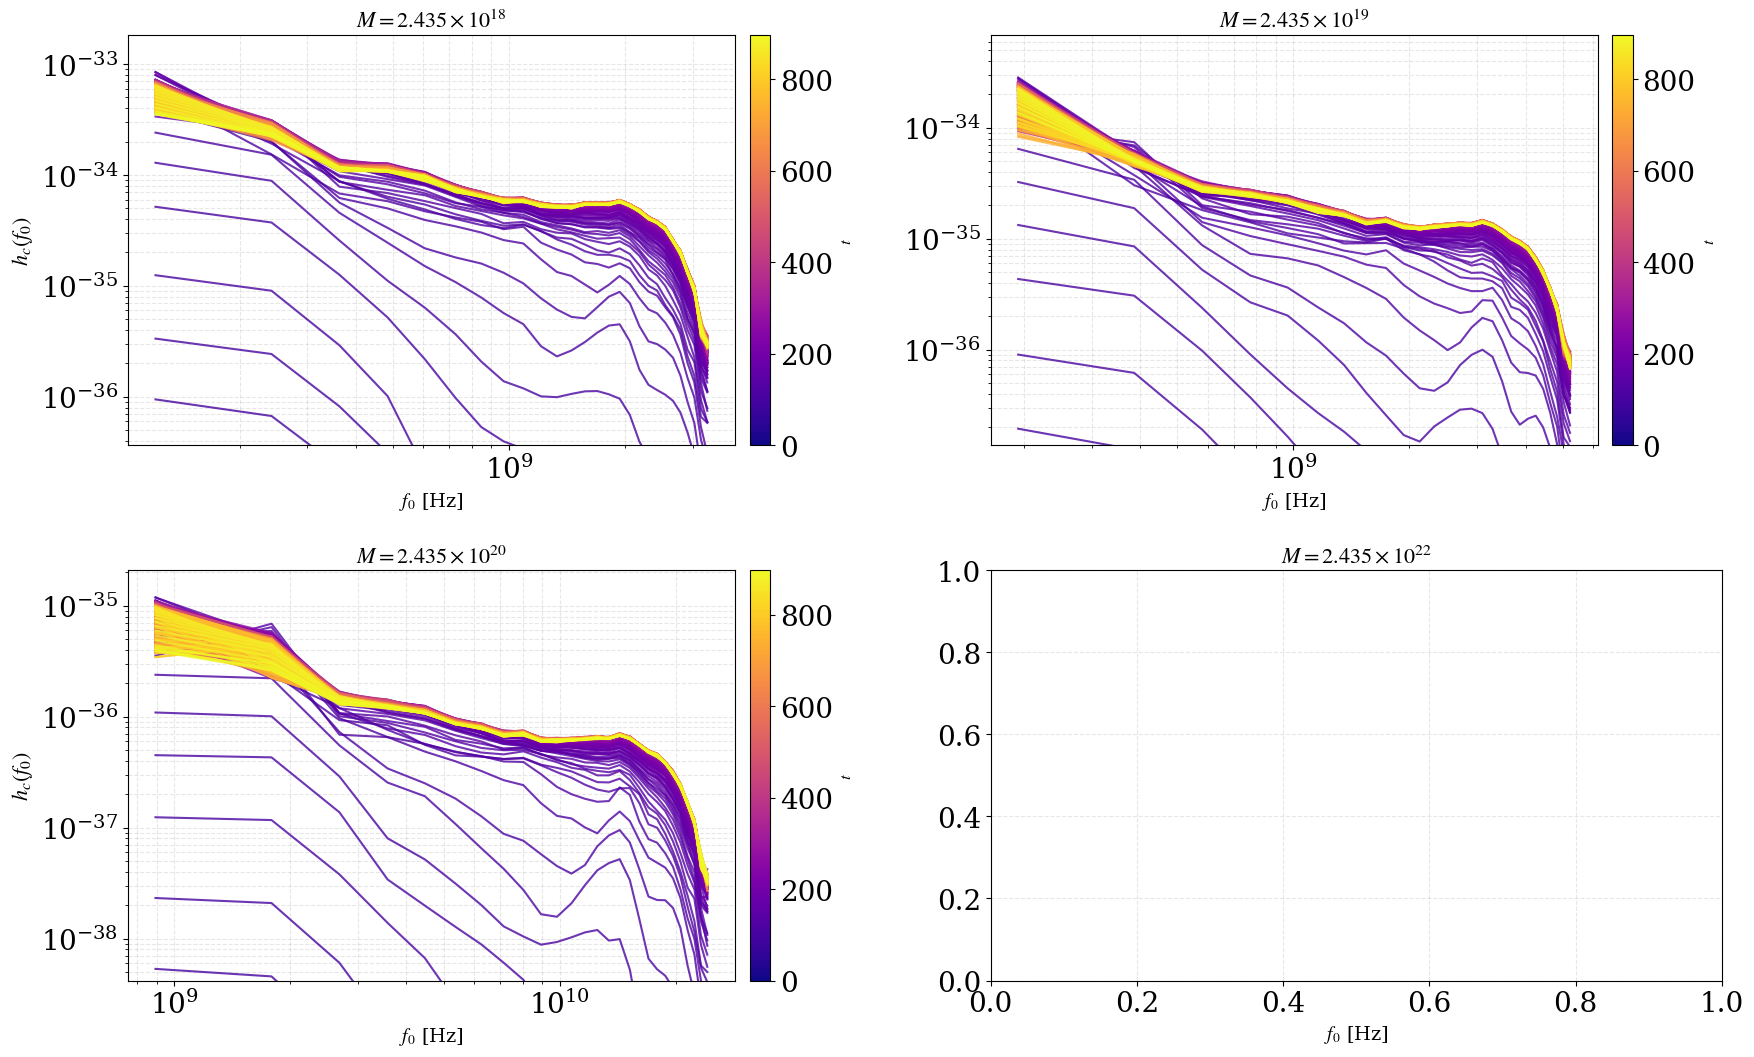

In [30]:
plot_full_rescaled_h_spectra_grid(
    dirs=[dir_tanh2_m1, dir_tanh2_m2, dir_tanh2_m3, dir_tanh2_m4], 
    q_val_labels=m_labels, 
    red_dot_indices=lista_rojos, 
    ms=[2.435e18, 2.435e19, 2.435e21, 2.435e22]
)